# **Taller Parcial 2**

**Fecha de entrega:**  Lunes 5 de mayo

Se tiene la base de datos ```bank_customers_satisfaction.csv``` la cual reporta la satisfacción de los consumidores con respecto a su banco y los servicios que este le presta.

La base de datos reporta las siguientes variables:

*   ```client_id```: id del cliente.
*   ```client_age```: edad del cliente.
*   ```customer_since```: desde que año es cliente del banco.
*   ```bank_account (yes/no)```: 	si tiene cuenta bancaria con el banco.
*   ```credit_card (yes/no)```: si tiene tarjeta de crédito con el banco.
*   ```mortgage (yes/no)```: si tiene hipoteca con el banco.
*   ```total_number_of_products```: número de productos financieros que tiene con el banco.
*   ```customer_income```: ingresos totales en US dollars al año del consumidor.
*   ```customer_debt```: monto actual de la deuda en US dollars que tiene el cliente con el banco.
*   ```city```: ciudad a la que pertenece la oficina del banco donde se registró el cliente en el banco.
*   ```bank```: banco con el que tiene los productos financieros el cliente.
*   ```branch```: oficina del banco donde se registró el cliente en el banco.
*   ```use_of_digital_channels (High/Moderate/Low)```: Nivel de uso de los canales digitales por parte del cliente.
*   ```use_of_branches (High/Moderate/Low)```: Nivel de uso de las oficinas del banco por parte del cliente.
*   ```bank_service_message```: opinión del cliente con respecto a su satisfacción general del servicio que le presta el banco.

## Informe solicitado

Usted trabaja de uno de los bancos reportados en la base de datos y se espera que usted haga un análisis que incluya lo siguiente:
1.   **```(60%)```** Creación de grupos homógeneos de los clientes en la base de datos, para enviarles una oferta de productos financieros acorde a sus necesidades. Reportando en cada grupo como es el sentimiento de los consumidores con respecto a su banco.
2.   **```(50%)```** Análisis y clasificación de las opiniones de los clientes con respecto a la satisfacción de los clientes en general con respecto a su banco.
  *   Nivel de satisfacción del cliente con su banco.
  *   Razón principal por la que está satisfecho o insatisfecho con su banco.
  *   Caracterización de la satisfacción de los clientes por otras variables.

## Nota
*   **Este trabajo es individual**, NO se permiten entregas iguales o similares.
*   **Uso de inteligencia artificial limitado**: el uso de inteligencia artificial es permitido, pero debe ser limitado, que se observe que el estudiante se apoya en ella, mas no que es un trabajo en su gran mayoría realizado por una inteligencia artificial.

---




# Rúbrica de evaluación

## Creación de grupos homógeneos (60%)

1.	Preprocesamiento de los datos (40%)
  *   Limpieza de los datos (25%)
  *   Transformación y creación de variables (15%)
2.	Exploración preliminar de los datos (10%)
  *   Gráficos de visualización
  *   Descripción de los hallazgos preliminares
3.	Desarrollo de modelos (25%)
  *   Selección de variables
  *   Preparación de variables
  *   Modelos analizados
  *   Modelo seleccionado y su justificación
  *   Presentación de los hallazgos
4.	Modelo entrenado guardado listo para asignar nuevas observaciones (10%)
5.	Informe ejecutivo de resultados (25%)

## Análisis y clasificación de la satisfacción de los clientes (50%)

1.	Procesamiento de los mensajes y creación de niveles de satisfacción (35%)
2.	Razón principal por la que está satisfecho o insatisfecho con su banco (25%)
3.	Informe ejecutivo de resultados (40%)

# Creación de grupos homogeneos

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans, DBSCAN

from scipy.cluster.hierarchy import dendrogram, linkage

In [3]:
path= "/content/drive/MyDrive/Colab aprendizaje no supervisado/Taller parcial 2/bank_customers_satisfaction.csv" # Colocar la ubicación del archivo
data= pd.read_csv(path) # Creamos el dataframe con los datos
data.head()

,client_id,client_age,customer_since,bank_account,credit_card,mortgage,total_number_of_products,customer_income,customer_debt,city,Bank,Branch,use_of_digital_channels,use_of_branches,bank_service_message
0,SHZV-1493-NEVC-8912,78,2016,no,yes,no,3,234567.54,417219.52,Chicago,Bank of America,Magnificent Mile,medium,low,I've had an excellent experience with the bank...
1,SULL-1078-YORL-8055,58,2018,no,no,no,0,16333.04,469993.65,Dallas,Wells Fargo,Main Street Dallas,low,medium,I've had an excellent experience with the bank...
2,WLYJ-9126-OZSF-4196,76,2007,yes,yes,yes,5,183418.08,147398.45,San Francisco,Bank of America,Embarcadero,medium,low,My recent interactions with the bank have been...
3,VZMD-7697-CKUK-6198,59,2002,yes,no,no,5,32490.32,80208.97,San Francisco,Bank of America,Embarcadero,high,medium,I've had an excellent experience with the bank...
4,WTBA-2990-KOZM-6501,67,2021,yes,no,no,2,38838.38,319814.33,Denver,Chase,Denver 16th Street,medium,high,My experience with the bank has been generally...


## **Limpieza de datos**

In [4]:
# Eliminar columnas innecesarias
data = data.drop(columns=['client_id'])
data.head()

,client_age,customer_since,bank_account,credit_card,mortgage,total_number_of_products,customer_income,customer_debt,city,Bank,Branch,use_of_digital_channels,use_of_branches,bank_service_message
0,78,2016,no,yes,no,3,234567.54,417219.52,Chicago,Bank of America,Magnificent Mile,medium,low,I've had an excellent experience with the bank...
1,58,2018,no,no,no,0,16333.04,469993.65,Dallas,Wells Fargo,Main Street Dallas,low,medium,I've had an excellent experience with the bank...
2,76,2007,yes,yes,yes,5,183418.08,147398.45,San Francisco,Bank of America,Embarcadero,medium,low,My recent interactions with the bank have been...
3,59,2002,yes,no,no,5,32490.32,80208.97,San Francisco,Bank of America,Embarcadero,high,medium,I've had an excellent experience with the bank...
4,67,2021,yes,no,no,2,38838.38,319814.33,Denver,Chase,Denver 16th Street,medium,high,My experience with the bank has been generally...


In [5]:
data.shape

(1000, 14)

In [6]:
# Detactar si hay algún dato atítico

def count_outliers(data, column_name):

    Q1 = data[column_name].quantile(0.25)
    Q3 = data[column_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column_name] < lower_bound) | (data[column_name] > upper_bound)]
    return len(outliers)

outliers_income = count_outliers(data, 'customer_income')
outliers_debt = count_outliers(data, 'customer_debt')

print(f"Número de datos atípicos en 'customer_income': {outliers_income}")
print(f"Número de datos atípicos en 'customer_debt': {outliers_debt}")


Número de datos atípicos en 'customer_income': 0
Número de datos atípicos en 'customer_debt': 0


In [7]:
data.head()

,client_age,customer_since,bank_account,credit_card,mortgage,total_number_of_products,customer_income,customer_debt,city,Bank,Branch,use_of_digital_channels,use_of_branches,bank_service_message
0,78,2016,no,yes,no,3,234567.54,417219.52,Chicago,Bank of America,Magnificent Mile,medium,low,I've had an excellent experience with the bank...
1,58,2018,no,no,no,0,16333.04,469993.65,Dallas,Wells Fargo,Main Street Dallas,low,medium,I've had an excellent experience with the bank...
2,76,2007,yes,yes,yes,5,183418.08,147398.45,San Francisco,Bank of America,Embarcadero,medium,low,My recent interactions with the bank have been...
3,59,2002,yes,no,no,5,32490.32,80208.97,San Francisco,Bank of America,Embarcadero,high,medium,I've had an excellent experience with the bank...
4,67,2021,yes,no,no,2,38838.38,319814.33,Denver,Chase,Denver 16th Street,medium,high,My experience with the bank has been generally...


## **Transformación y creación de variables**

In [8]:

data['time_as_customer'] = 2025 - data['customer_since']
data = data.drop(columns=['customer_since'])
data = data[['time_as_customer'] + [col for col in data.columns if col != 'time_as_customer']]
data.head()

,time_as_customer,client_age,bank_account,credit_card,mortgage,total_number_of_products,customer_income,customer_debt,city,Bank,Branch,use_of_digital_channels,use_of_branches,bank_service_message
0,9,78,no,yes,no,3,234567.54,417219.52,Chicago,Bank of America,Magnificent Mile,medium,low,I've had an excellent experience with the bank...
1,7,58,no,no,no,0,16333.04,469993.65,Dallas,Wells Fargo,Main Street Dallas,low,medium,I've had an excellent experience with the bank...
2,18,76,yes,yes,yes,5,183418.08,147398.45,San Francisco,Bank of America,Embarcadero,medium,low,My recent interactions with the bank have been...
3,23,59,yes,no,no,5,32490.32,80208.97,San Francisco,Bank of America,Embarcadero,high,medium,I've had an excellent experience with the bank...
4,4,67,yes,no,no,2,38838.38,319814.33,Denver,Chase,Denver 16th Street,medium,high,My experience with the bank has been generally...


In [9]:
data.value_counts('time_as_customer')

,count
time_as_customer,
3,55
1,49
2,44
5,40
6,39
7,37
8,35
14,34
9,33


In [10]:

min_client_age = data['client_age'].min()
max_client_age = data['client_age'].max()
print(f"El valor mínimo en la variable client_age es: {min_client_age}")
print(f"El valor máximo en la variable client_age es: {max_client_age}")


El valor mínimo en la variable client_age es: 18
El valor máximo en la variable client_age es: 85


In [11]:

# Definir rangos de edad
bins = [18, 30, 45, 60, float('inf')]
labels = ['18-29', '30-44', '45-59', '60+']

# Crear la nueva columna 'age_group'
data['age_group'] = pd.cut(data['client_age'], bins=bins, labels=labels, right=False)

# Mostrar las primeras filas de la columna
print(data[['client_age', 'age_group']].head())


   client_age age_group
0          78       60+
1          58     45-59
2          76       60+
3          59     45-59
4          67       60+


In [12]:

# Mover a la variable age_group a la posición original de client_age
cols = list(data.columns)
cols.insert(0, cols.pop(cols.index('age_group')))
data = data[cols]


In [13]:
data.value_counts('age_group')

,count
age_group,
60+,359
45-59,255
30-44,200
18-29,186


In [14]:

# Crear variables dummies para 'use_of_digital_channels'
digital_dummies = pd.get_dummies(data['use_of_digital_channels'], prefix='digital', dtype=int)
digital_dummies = digital_dummies[['digital_low', 'digital_medium', 'digital_high']]
data = pd.concat([data, digital_dummies], axis=1)

# Crear variables dummies para 'use_of_branches'
branch_dummies = pd.get_dummies(data['use_of_branches'], prefix='branch', dtype=int)
branch_dummies = branch_dummies[['branch_low', 'branch_medium', 'branch_high']]
data = pd.concat([data, branch_dummies], axis=1)

data.head()


,age_group,time_as_customer,client_age,bank_account,credit_card,mortgage,total_number_of_products,customer_income,customer_debt,city,...,Branch,use_of_digital_channels,use_of_branches,bank_service_message,digital_low,digital_medium,digital_high,branch_low,branch_medium,branch_high
0,60+,9,78,no,yes,no,3,234567.54,417219.52,Chicago,...,Magnificent Mile,medium,low,I've had an excellent experience with the bank...,0,1,0,1,0,0
1,45-59,7,58,no,no,no,0,16333.04,469993.65,Dallas,...,Main Street Dallas,low,medium,I've had an excellent experience with the bank...,1,0,0,0,1,0
2,60+,18,76,yes,yes,yes,5,183418.08,147398.45,San Francisco,...,Embarcadero,medium,low,My recent interactions with the bank have been...,0,1,0,1,0,0
3,45-59,23,59,yes,no,no,5,32490.32,80208.97,San Francisco,...,Embarcadero,high,medium,I've had an excellent experience with the bank...,0,0,1,0,1,0
4,60+,4,67,yes,no,no,2,38838.38,319814.33,Denver,...,Denver 16th Street,medium,high,My experience with the bank has been generally...,0,1,0,0,0,1


## **Gráficos de visualización**

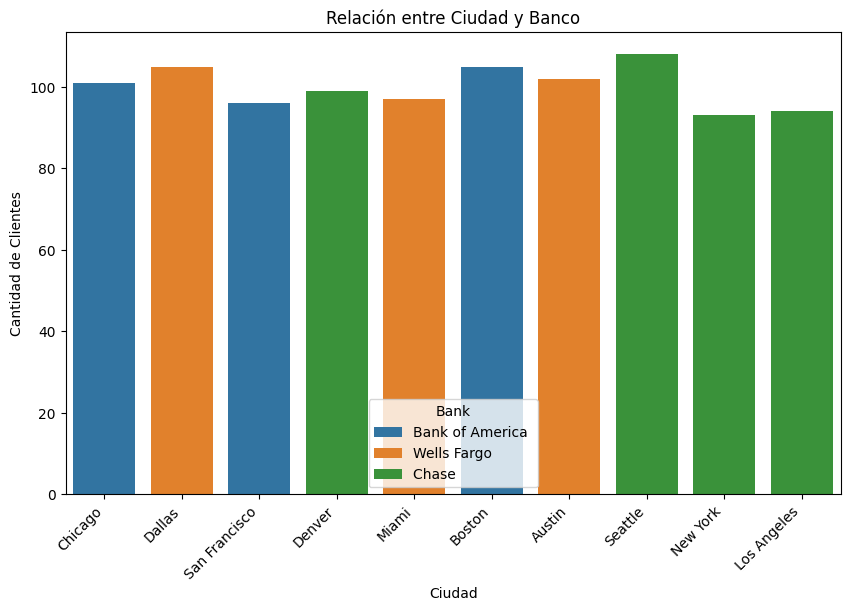

In [15]:
# Gráfica que determina que banco se usa en cada ciudad

plt.figure(figsize=(10, 6))
sns.countplot(x='city', hue='Bank', data=data)
plt.title('Relación entre Ciudad y Banco')
plt.xlabel('Ciudad')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=45, ha='right')
plt.show()


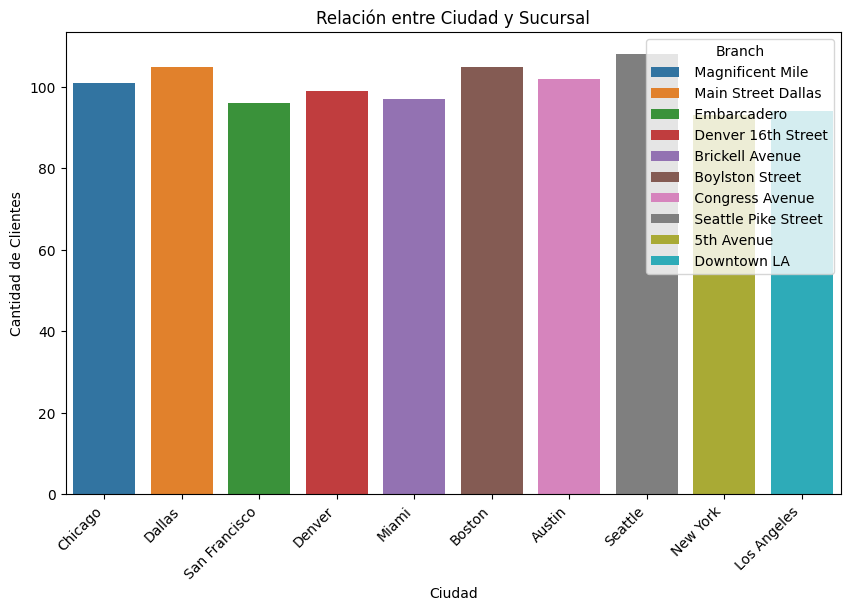

In [16]:
# Gráfica que determina que en que ciudad está cada sucursal

plt.figure(figsize=(10, 6))
sns.countplot(x='city', hue='Branch', data=data)
plt.title('Relación entre Ciudad y Sucursal')
plt.xlabel('Ciudad')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=45, ha='right')
plt.show()


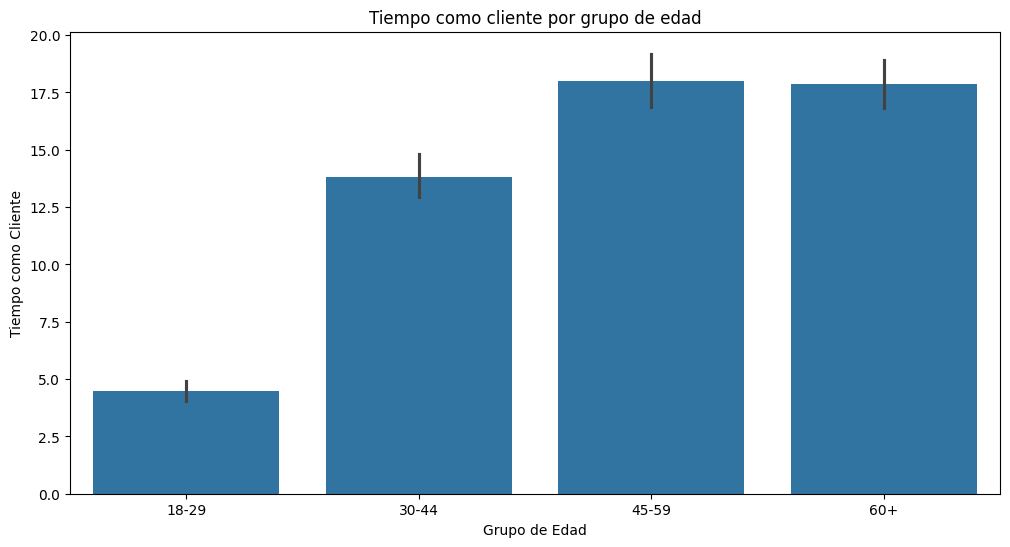

In [17]:
# Gráfica que relaciona el tiempo como cliente por cada grupo de edad

plt.figure(figsize=(12, 6))
sns.barplot(x='age_group', y='time_as_customer', data=data)
plt.title('Tiempo como cliente por grupo de edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Tiempo como Cliente')
plt.show()


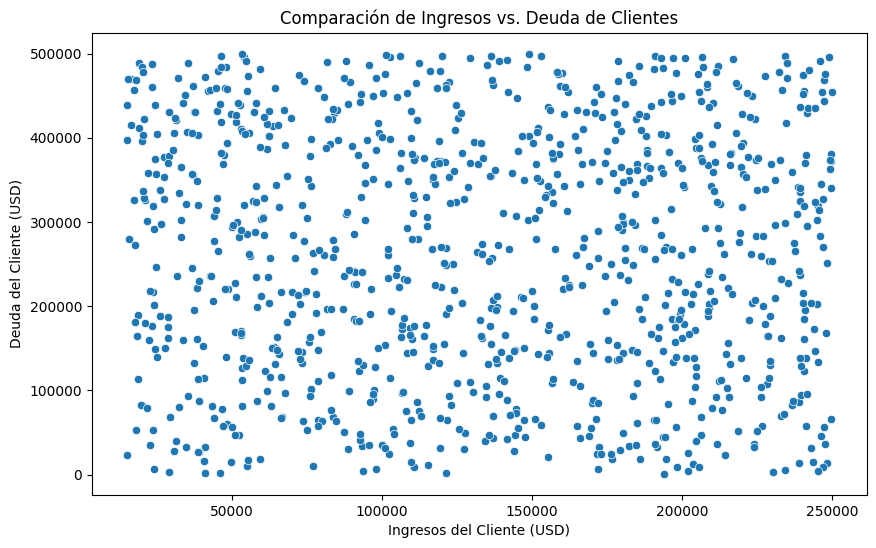

In [18]:
# Gráfica que compara los ingresos y las deudad de todos los clientes.

plt.figure(figsize=(10, 6))
sns.scatterplot(x='customer_income', y='customer_debt', data=data)
plt.title('Comparación de Ingresos vs. Deuda de Clientes')
plt.xlabel('Ingresos del Cliente (USD)')
plt.ylabel('Deuda del Cliente (USD)')
plt.show()


## **Descripción de hallazgos**

Bank of America tiene presencia en Chicago, San Francisco y Boston.

Wells Fargo tiene presencia en Dallas, Miami y Austin.

Chase tiene presencia en Denver, Seattle, New York y Los Angeles.

---
Bank of America:
*   Magnificent Mile está en Chicago.
*   Embarcadero está en San Francisco.
*   Boylston Street está en Boston.

Wells Fargo
*   Main Street Dallas está en Dallas.
*   Brickell Avenue está en Miami.
*   Congress Avenue está en Austin.

Chase
*   Denver 16th Street está en Denver.
*   Seattle Pike Street está en Seattle.
*   5th Avenue está en New York.
*   Downtown LA está en Los Angeles.
---
En el rango de 18 a 29 años, el tiempo como cliente está entre los 0 y los 5 años en promedio.

En el rango de 30 a 44 años, el tiempo como cliente puede llegar hasta los 13 años en promedio.

En el rango de 45 a 59 años, el tiempo como cliente puede llegar hasta los 18 años en promedio.

En el rango de más de 60 años, el tiempo como cliente también puede alcanzar los 18 años en promedio.

---
No se encuentran áreas de alta densidad en la comparación entre ingreso y deuda, la ausencia de un patrón claro podría indicar que el ingreso de un cliente no necesariamente predice su nivel de deuda.











## **Selección de variables**

In [19]:
data.columns # Para conocer el nombre de las columnas

Index(['age_group', 'time_as_customer', 'client_age', 'bank_account',
       'credit_card', 'mortgage', 'total_number_of_products',
       'customer_income', 'customer_debt', 'city', 'Bank', 'Branch',
       'use_of_digital_channels', 'use_of_branches', 'bank_service_message',
       'digital_low', 'digital_medium', 'digital_high', 'branch_low',
       'branch_medium', 'branch_high'],
      dtype='object')

In [20]:
data_cat=data[['client_age','customer_income','customer_debt','time_as_customer','total_number_of_products']]


In [21]:
data_cat.head()

,client_age,customer_income,customer_debt,time_as_customer,total_number_of_products
0,78,234567.54,417219.52,9,3
1,58,16333.04,469993.65,7,0
2,76,183418.08,147398.45,18,5
3,59,32490.32,80208.97,23,5
4,67,38838.38,319814.33,4,2


In [22]:
corr_matrix = data_cat.corr()
corr_matrix

,client_age,customer_income,customer_debt,time_as_customer,total_number_of_products
client_age,1.000000,0.003375,-0.017308,0.424111,0.011480
customer_income,0.003375,1.000000,-0.019718,0.018673,-0.044435
customer_debt,-0.017308,-0.019718,1.000000,-0.001394,0.038201
time_as_customer,0.424111,0.018673,-0.001394,1.000000,-0.023246
total_number_of_products,0.011480,-0.044435,0.038201,-0.023246,1.000000


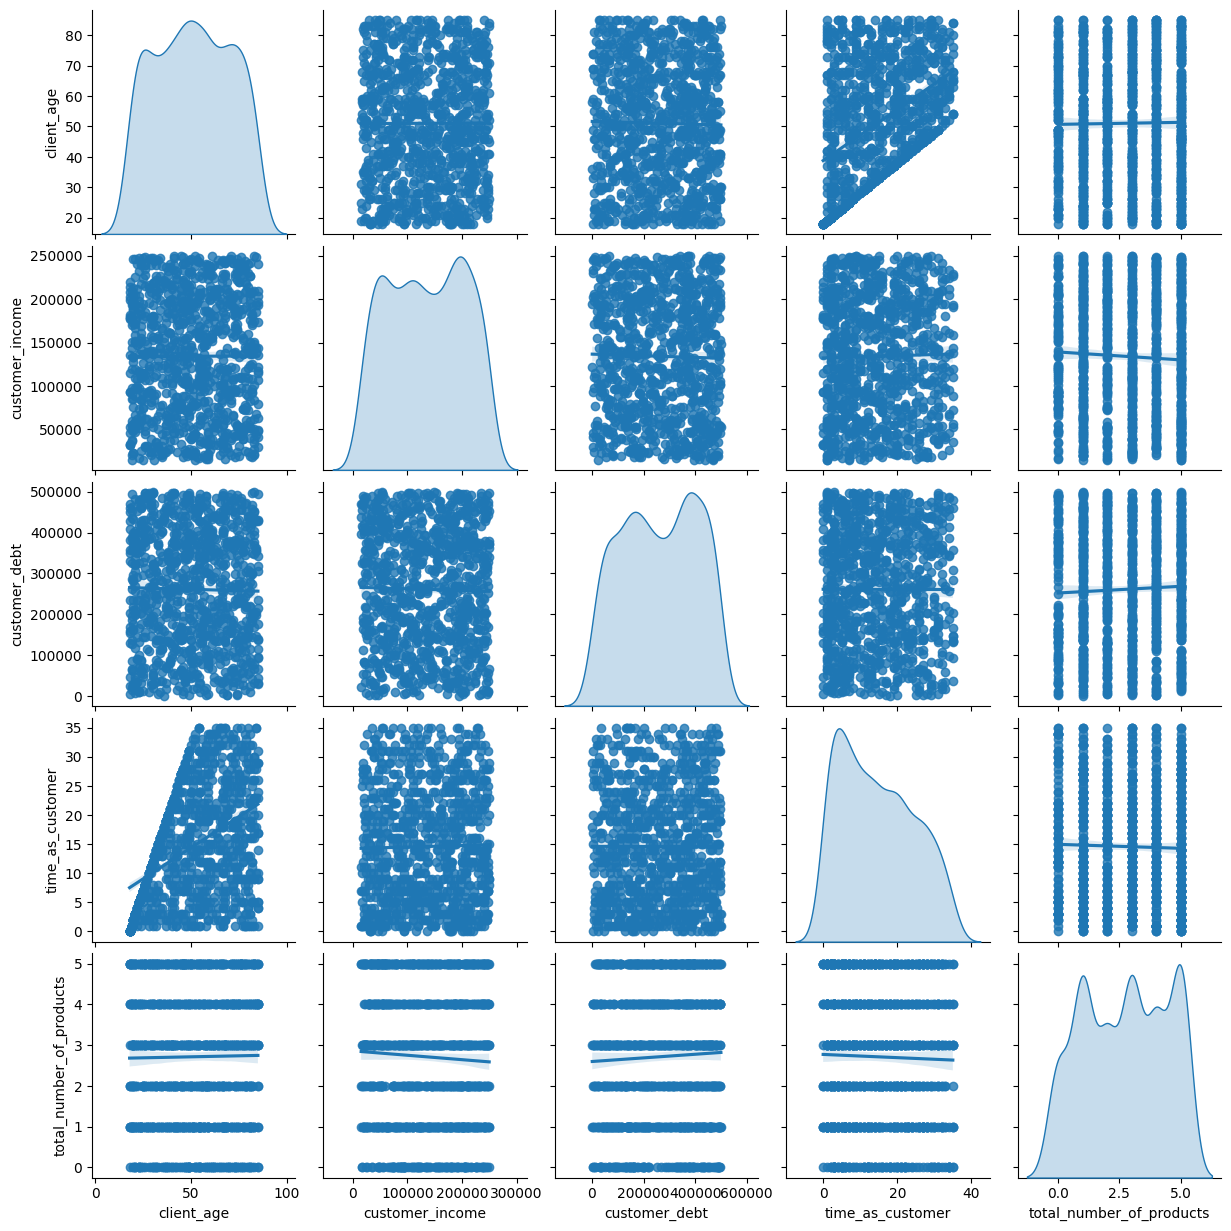

In [23]:
sns.pairplot(data_cat, kind="reg", diag_kind="kde")
plt.show()


## **Prepación de variables**

In [24]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data_cat)
scaled_features

array([[ 1.37433739,  1.4508512 ,  1.08010834, -0.566653  ,  0.16936181],
       [ 0.35396662, -1.70577219,  1.44517475, -0.76888461, -1.61339409],
       [ 1.27230031,  0.71100676, -0.78638592,  0.34338929,  1.35786575],
       ...,
       [-0.76844123, -1.3981208 ,  1.17005382,  0.24227348,  0.16936181],
       [ 1.62943008, -1.64646107,  0.98313853,  0.84896834, -1.01914212],
       [-0.61538561,  1.53445581,  1.32013584,  0.64673672,  0.16936181]])

In [25]:
est=pd.DataFrame(scaled_features, columns=data_cat.columns)
est

,client_age,customer_income,customer_debt,time_as_customer,total_number_of_products
0,1.374337,1.450851,1.080108,-0.566653,0.169362
1,0.353967,-1.705772,1.445175,-0.768885,-1.613394
2,1.272300,0.711007,-0.786386,0.343389,1.357866
3,0.404985,-1.472067,-1.251171,0.848968,1.357866
4,0.813133,-1.380247,0.406305,-1.072232,-0.424890
...,...,...,...,...,...
995,-1.023534,-0.169387,0.424404,-0.162190,1.357866
996,0.047855,0.821173,-0.953949,0.747853,-1.613394
997,-0.768441,-1.398121,1.170054,0.242273,0.169362
998,1.629430,-1.646461,0.983139,0.848968,-1.019142


## **Modelos analizados**

In [26]:
kmeans = KMeans(
  init="random", # Este parámetro determina donde se ubican los centroides inicialmente
  n_clusters=5, # Corresponde al número de clusters que se van a crear
  n_init=10, # El número de veces que se iniciarán los centroides para seleccionar los mejores, según la inercia
  max_iter=300, # Número máximo de iteraciones para encontrar los clusters optimos
  random_state=42 # Este valor asegura que los resultados son reproducibles
  )

In [27]:
kmeans.fit(scaled_features)

KMeans(init='random', n_clusters=5, n_init=10, random_state=42)

In [28]:
kmeans.inertia_ # es la medida de la suma de las distancias al cuadrado entre cada punto y el centroide.
# Entre menor sea este valor, generalmente indica una mejor clusterización.
# Pero esta no debería ser la medida que determina el número de clusters.

2823.679055826784

In [29]:
kmeans.cluster_centers_ # Muestra los centroides de los clusters

array([[-0.81267405, -0.57668084,  0.84985891, -0.71160226, -0.06482616],
       [ 0.56161684,  0.41990324, -0.18891865,  0.69965714, -1.03580339],
       [ 0.79134163, -0.93586868, -0.29945243,  0.58220552,  0.5934009 ],
       [-0.94195882,  0.15356907, -0.93042629, -0.79700238, -0.18337599],
       [ 0.32211241,  0.93770238,  0.51516742,  0.14167095,  0.76663029]])

In [30]:
standardized_centroids = kmeans.cluster_centers_

original_centroids = scaler.inverse_transform(standardized_centroids)
original_centroids

array([[3.51330049e+01, 9.43932502e+04, 3.83934581e+05, 7.56650246e+00,
        2.60591133e+00],
       [6.20700935e+01, 1.63292514e+05, 2.33768530e+05, 2.15233645e+01,
        9.71962617e-01],
       [6.65728643e+01, 6.95606466e+04, 2.17789728e+05, 2.03618090e+01,
        3.71356784e+00],
       [3.25989305e+01, 1.44879389e+05, 1.26575924e+05, 6.72192513e+00,
        2.40641711e+00],
       [5.73756345e+01, 1.99090778e+05, 3.35551461e+05, 1.60050761e+01,
        4.00507614e+00]])

In [31]:
labels = kmeans.predict(scaled_features)
data['cluster'] = labels
data

,age_group,time_as_customer,client_age,bank_account,credit_card,mortgage,total_number_of_products,customer_income,customer_debt,city,...,use_of_digital_channels,use_of_branches,bank_service_message,digital_low,digital_medium,digital_high,branch_low,branch_medium,branch_high,cluster
0,60+,9,78,no,yes,no,3,234567.54,417219.52,Chicago,...,medium,low,I've had an excellent experience with the bank...,0,1,0,1,0,0,4
1,45-59,7,58,no,no,no,0,16333.04,469993.65,Dallas,...,low,medium,I've had an excellent experience with the bank...,1,0,0,0,1,0,0
2,60+,18,76,yes,yes,yes,5,183418.08,147398.45,San Francisco,...,medium,low,My recent interactions with the bank have been...,0,1,0,1,0,0,4
3,45-59,23,59,yes,no,no,5,32490.32,80208.97,San Francisco,...,high,medium,I've had an excellent experience with the bank...,0,0,1,0,1,0,2
4,60+,4,67,yes,no,no,2,38838.38,319814.33,Denver,...,medium,high,My experience with the bank has been generally...,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,30-44,13,31,no,yes,yes,5,122551.65,322430.65,Denver,...,medium,low,I've had an excellent experience with the bank...,0,1,0,1,0,0,0
996,45-59,22,52,no,no,no,0,191034.48,123175.50,Boston,...,high,low,I've had an excellent experience with the bank...,0,0,1,1,0,0,1
997,30-44,17,36,no,yes,yes,3,37602.65,430222.07,Seattle,...,high,high,I've had an excellent experience with the bank...,0,0,1,0,0,1,0
998,60+,23,83,no,yes,yes,1,20433.54,403201.53,Miami,...,medium,low,I've had an excellent experience with the bank...,0,1,0,1,0,0,2


**Número de clusters a crear**

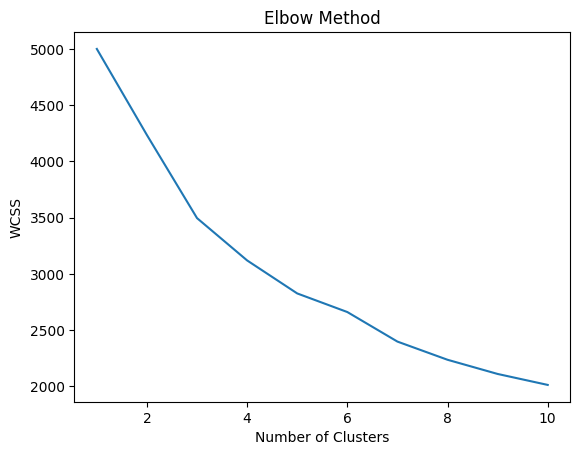

In [32]:
wcss = [] # crear una lista para almacenar los valores de WCSS

# Calcular el WCSS para diferentes valores de k
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Gráfico del codo
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [33]:
cluster_counts = data['cluster'].value_counts()
cluster_counts

,count
cluster,
1,214
0,203
2,199
4,197
3,187


**Edad vs ingresos**

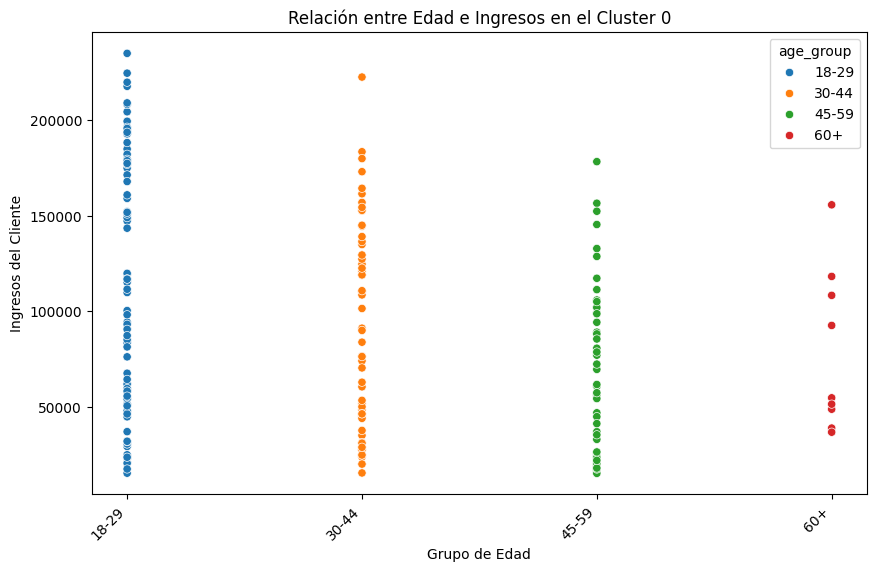

In [34]:

import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar el DataFrame para incluir solo el cluster 0
cluster_0 = data[data['cluster'] == 0]

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age_group', y='customer_income', data=cluster_0, hue='age_group')
plt.title('Relación entre Edad e Ingresos en el Cluster 0')
plt.xlabel('Grupo de Edad')
plt.ylabel('Ingresos del Cliente')
plt.xticks(rotation=45, ha='right')  # Rotar las etiquetas del eje x para mejor legibilidad
plt.show()


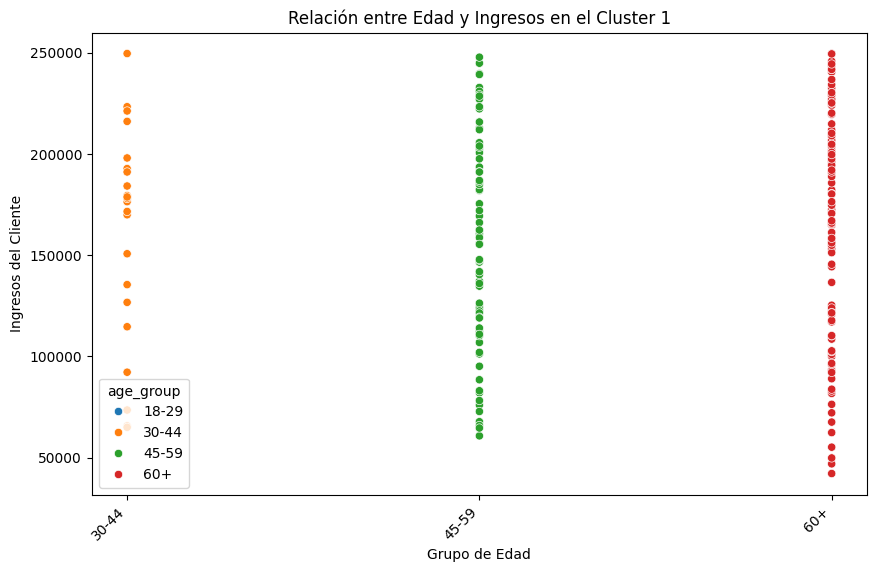

In [35]:

import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar el DataFrame para incluir solo el cluster 1
cluster_1 = data[data['cluster'] == 1]

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age_group', y='customer_income', data=cluster_1, hue='age_group')
plt.title('Relación entre Edad y Ingresos en el Cluster 1')
plt.xlabel('Grupo de Edad')
plt.ylabel('Ingresos del Cliente')
plt.xticks(rotation=45, ha='right')  # Rotar las etiquetas del eje x para mejor legibilidad
plt.show()


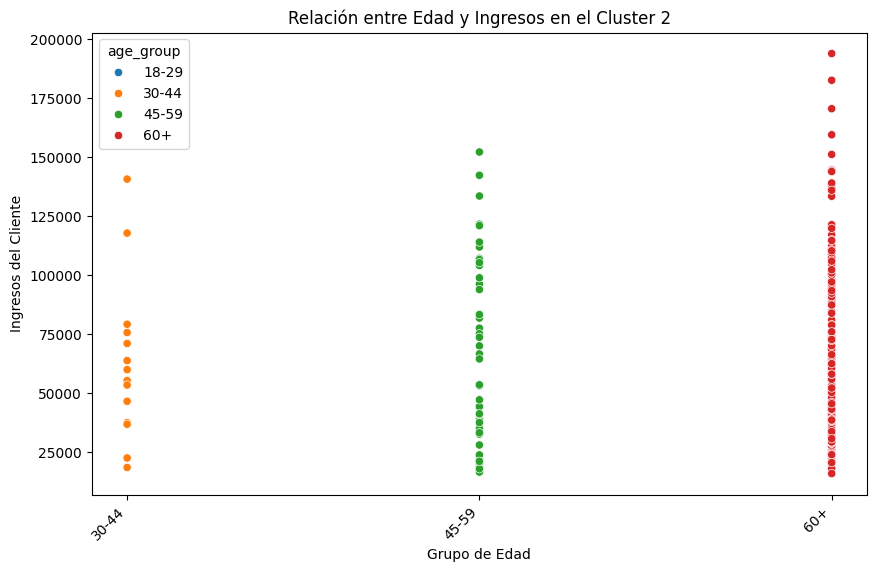

In [36]:

import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar el DataFrame para incluir solo el cluster 2
cluster_2 = data[data['cluster'] == 2]

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age_group', y='customer_income', data=cluster_2, hue='age_group')
plt.title('Relación entre Edad y Ingresos en el Cluster 2')
plt.xlabel('Grupo de Edad')
plt.ylabel('Ingresos del Cliente')
plt.xticks(rotation=45, ha='right')  # Rotar las etiquetas del eje x para mejor legibilidad
plt.show()


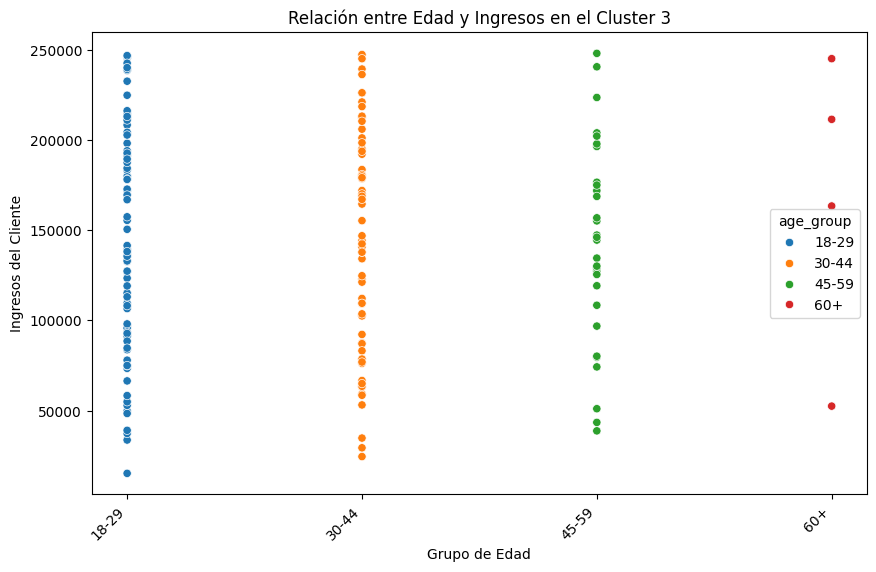

In [37]:

import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar el DataFrame para incluir solo el cluster 3
cluster_3 = data[data['cluster'] == 3]

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age_group', y='customer_income', data=cluster_3, hue='age_group')
plt.title('Relación entre Edad y Ingresos en el Cluster 3')
plt.xlabel('Grupo de Edad')
plt.ylabel('Ingresos del Cliente')
plt.xticks(rotation=45, ha='right')  # Rotar las etiquetas del eje x para mejor legibilidad
plt.show()


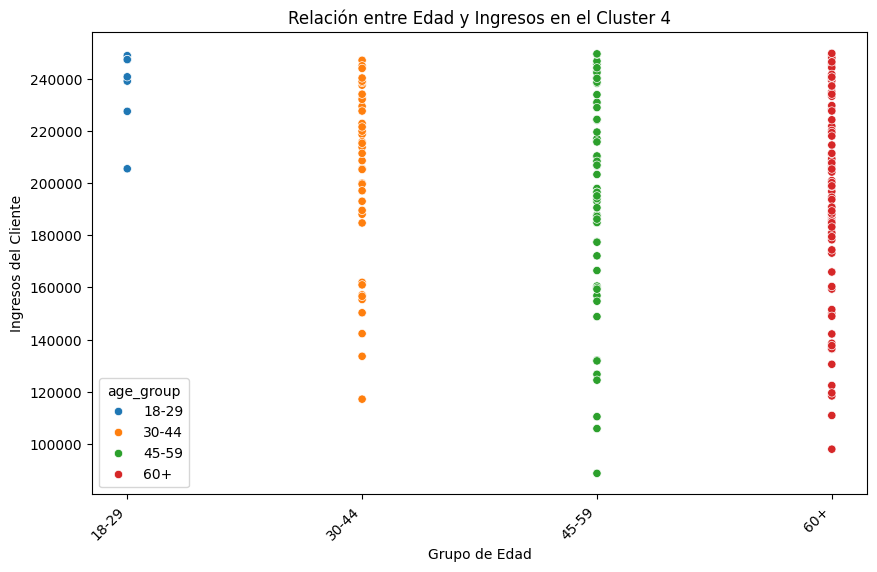

In [38]:


import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar el DataFrame para incluir solo el cluster 4
cluster_4 = data[data['cluster'] == 4]

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age_group', y='customer_income', data=cluster_4, hue='age_group')
plt.title('Relación entre Edad y Ingresos en el Cluster 4')
plt.xlabel('Grupo de Edad')
plt.ylabel('Ingresos del Cliente')
plt.xticks(rotation=45, ha='right')  # Rotar las etiquetas del eje x para mejor legibilidad
plt.show()


**Edad vs deuda**

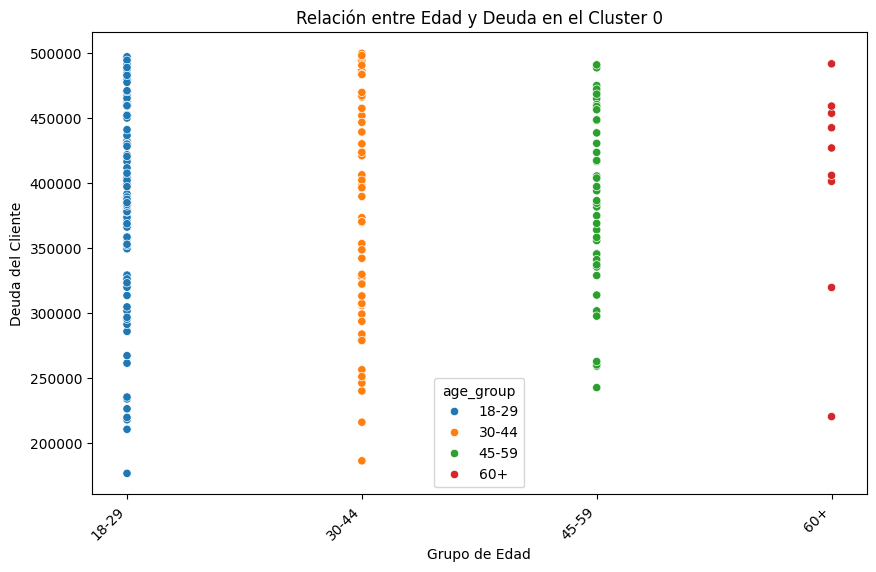

In [39]:

# Filtrar el DataFrame para incluir solo el cluster 0
cluster_0 = data[data['cluster'] == 0]

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age_group', y='customer_debt', data=cluster_0, hue='age_group')
plt.title('Relación entre Edad y Deuda en el Cluster 0')
plt.xlabel('Grupo de Edad')
plt.ylabel('Deuda del Cliente')
plt.xticks(rotation=45, ha='right')  # Rotar las etiquetas del eje x para mejor legibilidad
plt.show()


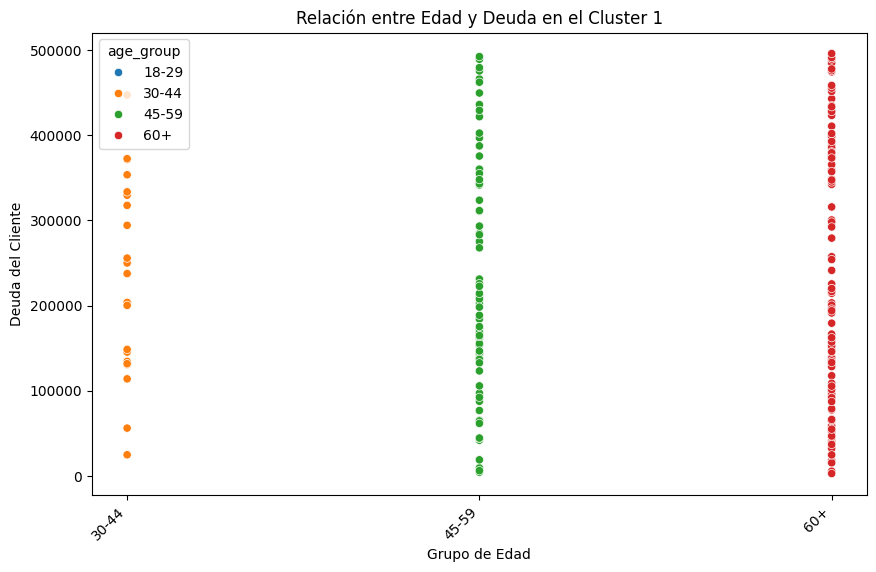

In [40]:

# Filtrar el DataFrame para incluir solo el cluster 1
cluster_1 = data[data['cluster'] == 1]

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age_group', y='customer_debt', data=cluster_1, hue='age_group')
plt.title('Relación entre Edad y Deuda en el Cluster 1')
plt.xlabel('Grupo de Edad')
plt.ylabel('Deuda del Cliente')
plt.xticks(rotation=45, ha='right')  # Rotar las etiquetas del eje x para mejor legibilidad
plt.show()


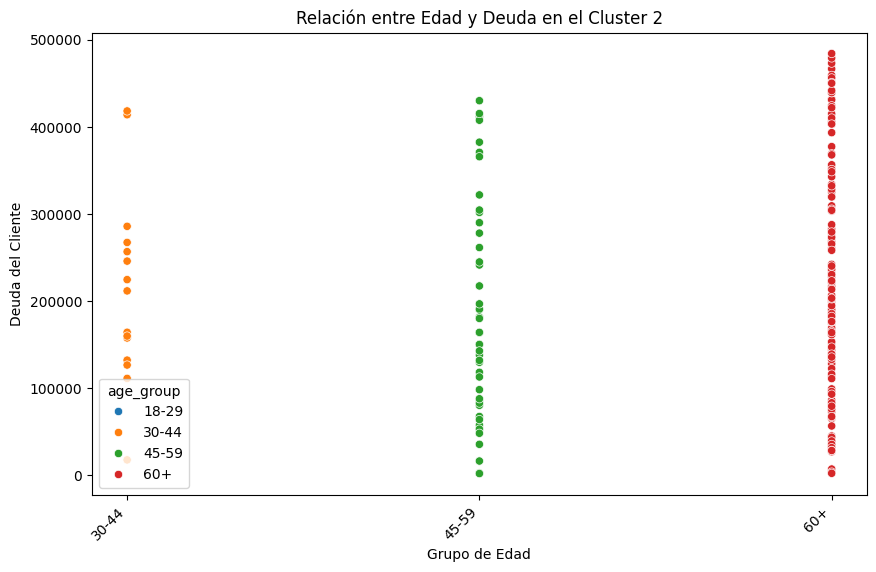

In [41]:

# Filtrar el DataFrame para incluir solo el cluster 2
cluster_2 = data[data['cluster'] == 2]

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age_group', y='customer_debt', data=cluster_2, hue='age_group')
plt.title('Relación entre Edad y Deuda en el Cluster 2')
plt.xlabel('Grupo de Edad')
plt.ylabel('Deuda del Cliente')
plt.xticks(rotation=45, ha='right')  # Rotar las etiquetas del eje x para mejor legibilidad
plt.show()


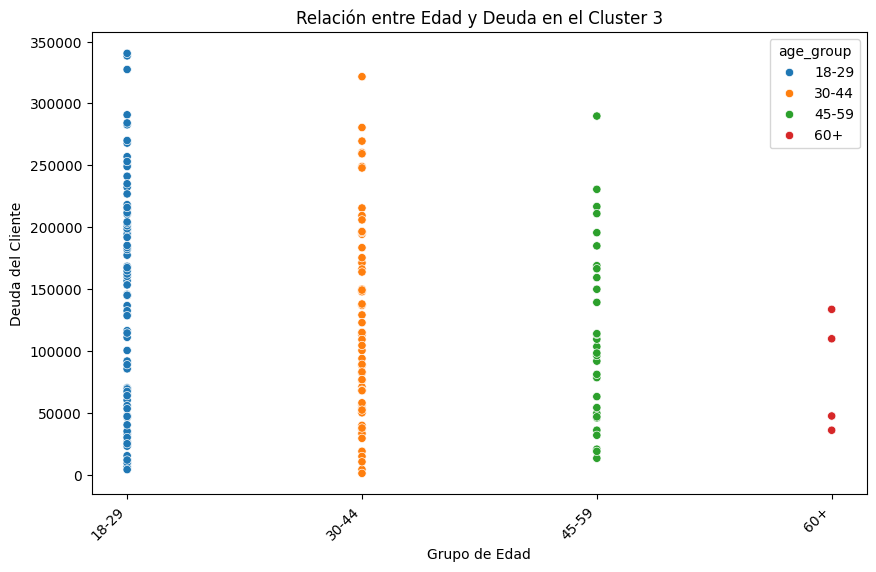

In [42]:

# Filtrar el DataFrame para incluir solo el cluster 3
cluster_3 = data[data['cluster'] == 3]

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age_group', y='customer_debt', data=cluster_3, hue='age_group')
plt.title('Relación entre Edad y Deuda en el Cluster 3')
plt.xlabel('Grupo de Edad')
plt.ylabel('Deuda del Cliente')
plt.xticks(rotation=45, ha='right')  # Rotar las etiquetas del eje x para mejor legibilidad
plt.show()


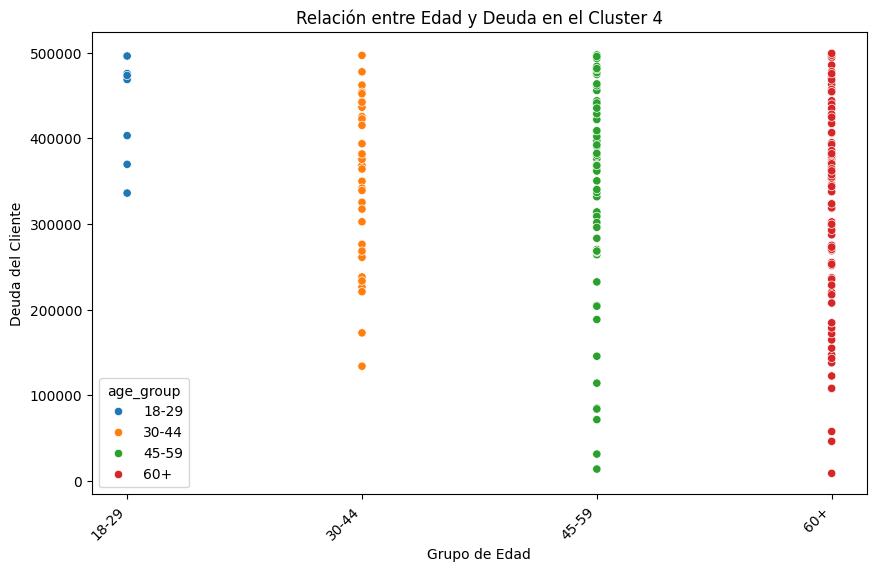

In [43]:

# Filtrar el DataFrame para incluir solo el cluster 4
cluster_4 = data[data['cluster'] == 4]

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age_group', y='customer_debt', data=cluster_4, hue='age_group')
plt.title('Relación entre Edad y Deuda en el Cluster 4')
plt.xlabel('Grupo de Edad')
plt.ylabel('Deuda del Cliente')
plt.xticks(rotation=45, ha='right')  # Rotar las etiquetas del eje x para mejor legibilidad
plt.show()


**Edad vs antiguedad**

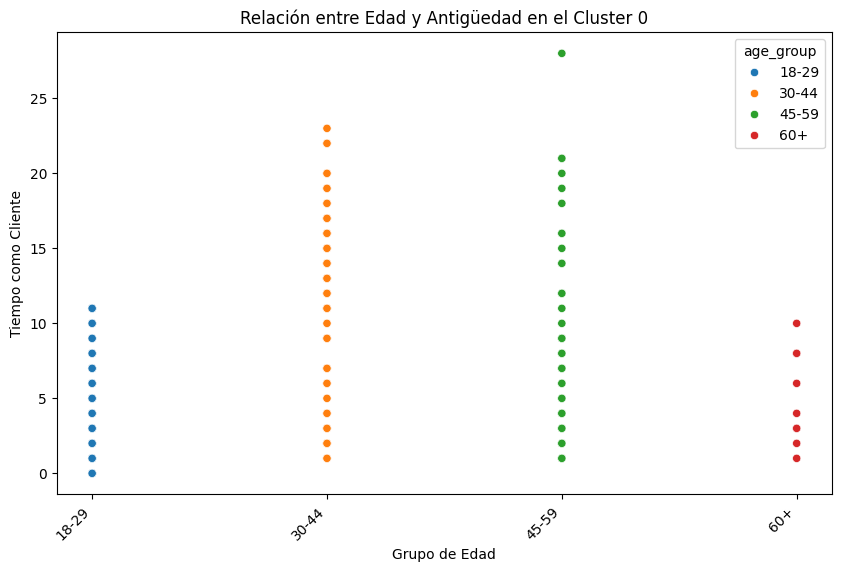

In [44]:

# Filtrar el DataFrame para incluir solo el cluster 0
cluster_0 = data[data['cluster'] == 0]

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age_group', y='time_as_customer', data=cluster_0, hue='age_group')
plt.title('Relación entre Edad y Antigüedad en el Cluster 0')
plt.xlabel('Grupo de Edad')
plt.ylabel('Tiempo como Cliente')
plt.xticks(rotation=45, ha='right')  # Rotar las etiquetas del eje x para mejor legibilidad
plt.show()


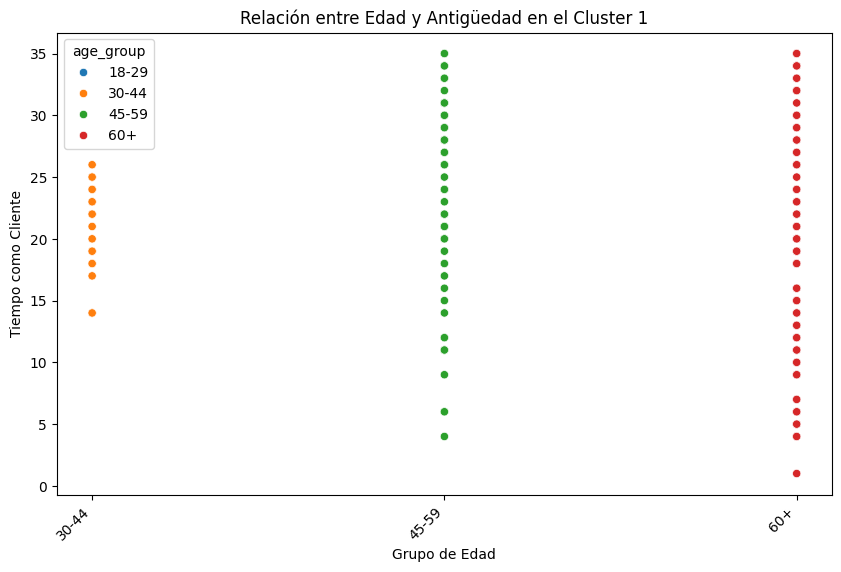

In [45]:

# Filtrar el DataFrame para incluir solo el cluster 1
cluster_1 = data[data['cluster'] == 1]

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age_group', y='time_as_customer', data=cluster_1, hue='age_group')
plt.title('Relación entre Edad y Antigüedad en el Cluster 1')
plt.xlabel('Grupo de Edad')
plt.ylabel('Tiempo como Cliente')
plt.xticks(rotation=45, ha='right')  # Rotar las etiquetas del eje x para mejor legibilidad
plt.show()


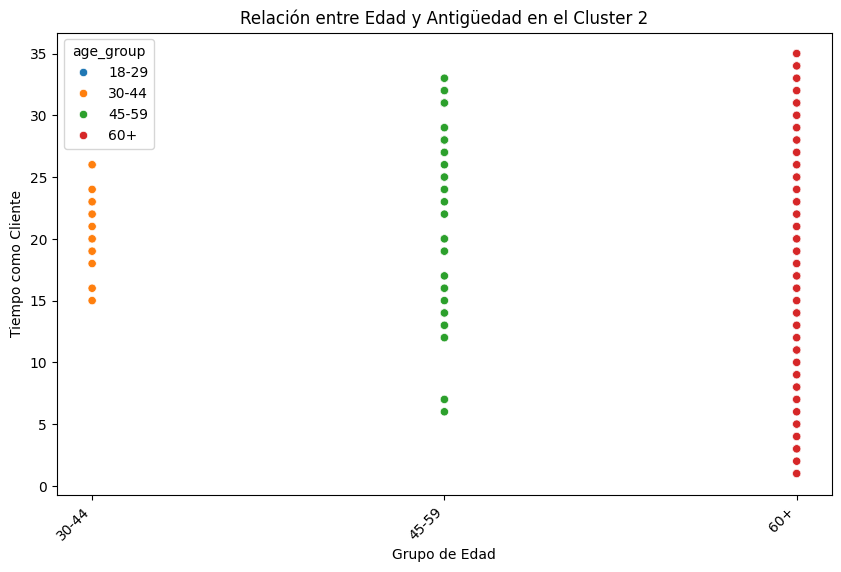

In [46]:

# Filtrar el DataFrame para incluir solo el cluster 2
cluster_2 = data[data['cluster'] == 2]

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age_group', y='time_as_customer', data=cluster_2, hue='age_group')
plt.title('Relación entre Edad y Antigüedad en el Cluster 2')
plt.xlabel('Grupo de Edad')
plt.ylabel('Tiempo como Cliente')
plt.xticks(rotation=45, ha='right')  # Rotar las etiquetas del eje x para mejor legibilidad
plt.show()


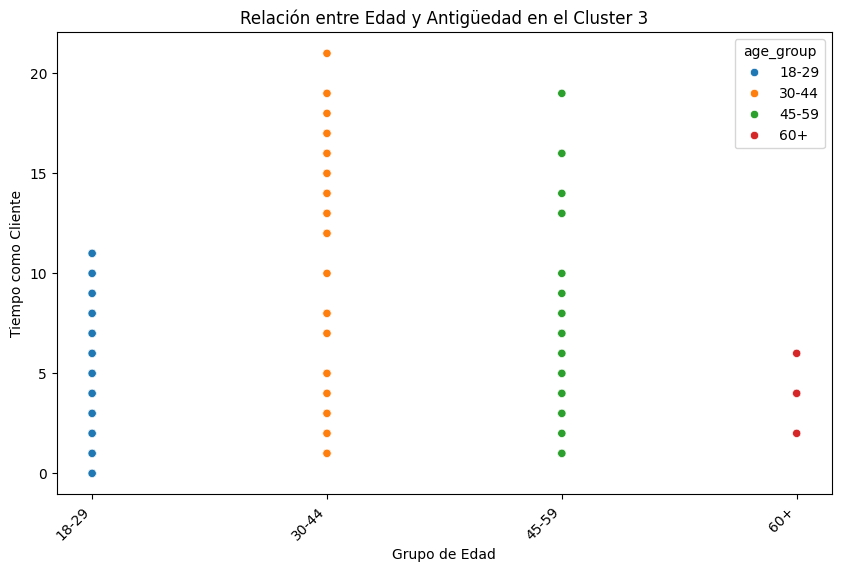

In [47]:

# Filtrar el DataFrame para incluir solo el cluster 3
cluster_3 = data[data['cluster'] == 3]

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age_group', y='time_as_customer', data=cluster_3, hue='age_group')
plt.title('Relación entre Edad y Antigüedad en el Cluster 3')
plt.xlabel('Grupo de Edad')
plt.ylabel('Tiempo como Cliente')
plt.xticks(rotation=45, ha='right')  # Rotar las etiquetas del eje x para mejor legibilidad
plt.show()


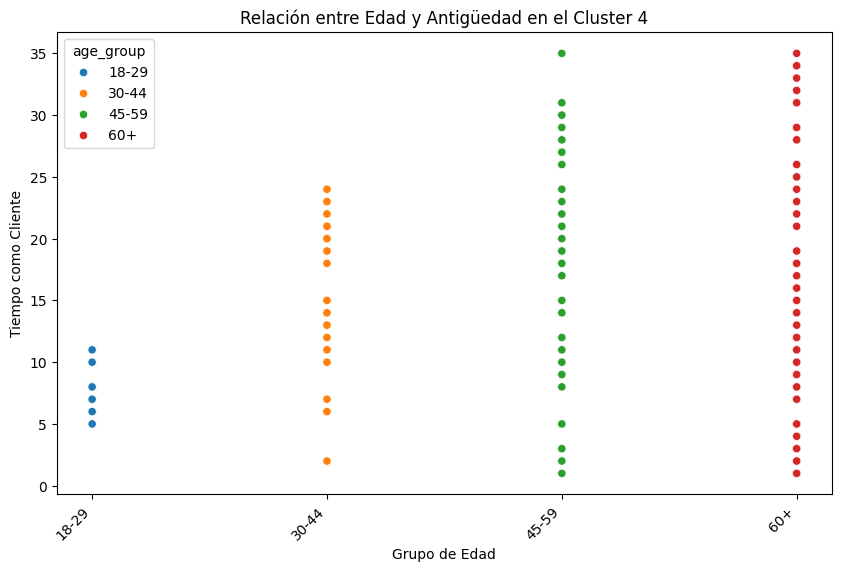

In [48]:

# Filtrar el DataFrame para incluir solo el cluster 4
cluster_4 = data[data['cluster'] == 4]

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age_group', y='time_as_customer', data=cluster_4, hue='age_group')
plt.title('Relación entre Edad y Antigüedad en el Cluster 4')
plt.xlabel('Grupo de Edad')
plt.ylabel('Tiempo como Cliente')
plt.xticks(rotation=45, ha='right')  # Rotar las etiquetas del eje x para mejor legibilidad
plt.show()


**Edad vs número de productos**

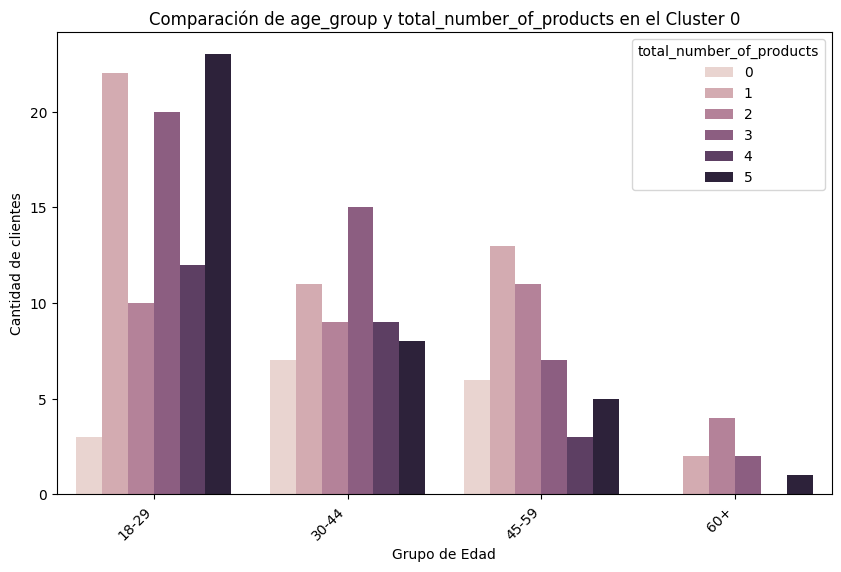

In [49]:

import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar el DataFrame para incluir solo el cluster 0
cluster_0 = data[data['cluster'] == 0]

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.countplot(x='age_group', hue='total_number_of_products', data=cluster_0)
plt.title('Comparación de age_group y total_number_of_products en el Cluster 0')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=45, ha='right')
plt.show()


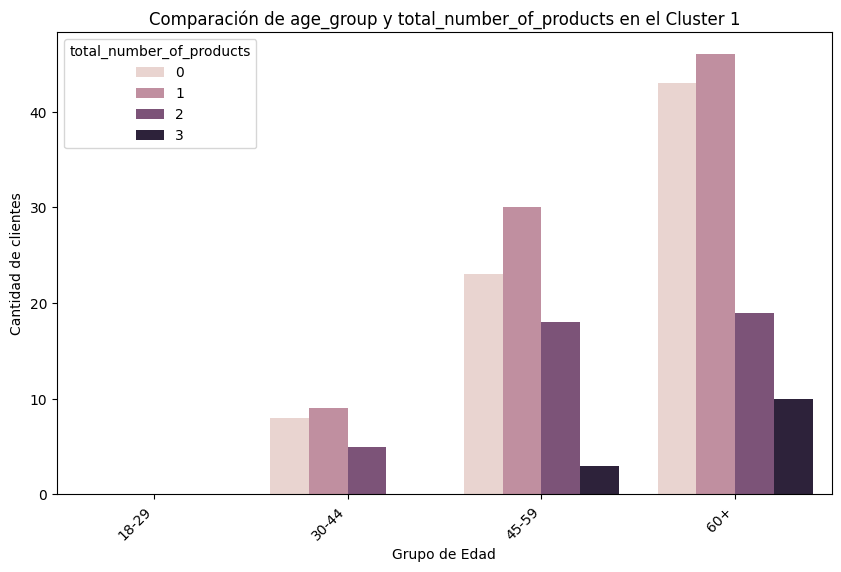

In [50]:

import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar el DataFrame para incluir solo el cluster 1
cluster_1 = data[data['cluster'] == 1]

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.countplot(x='age_group', hue='total_number_of_products', data=cluster_1)
plt.title('Comparación de age_group y total_number_of_products en el Cluster 1')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=45, ha='right')
plt.show()


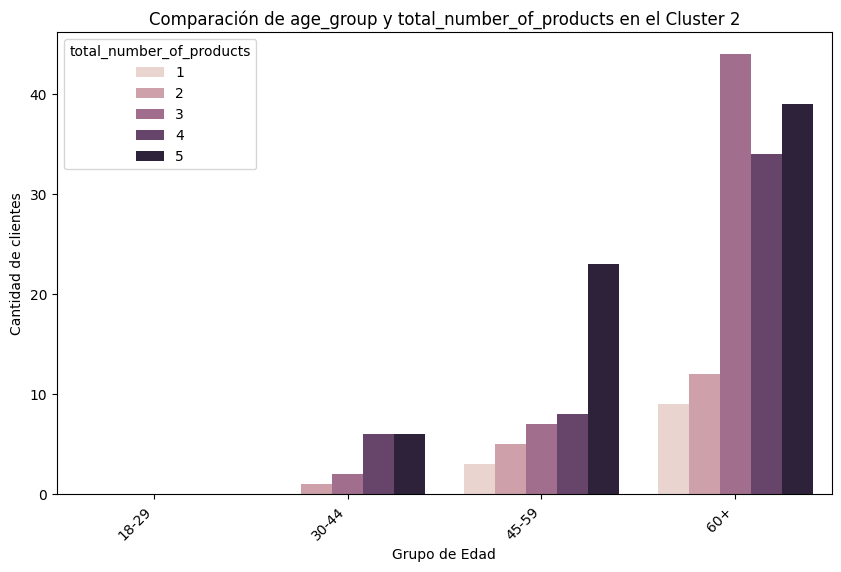

In [51]:

import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar el DataFrame para incluir solo el cluster 2
cluster_2 = data[data['cluster'] == 2]

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.countplot(x='age_group', hue='total_number_of_products', data=cluster_2)
plt.title('Comparación de age_group y total_number_of_products en el Cluster 2')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=45, ha='right')
plt.show()


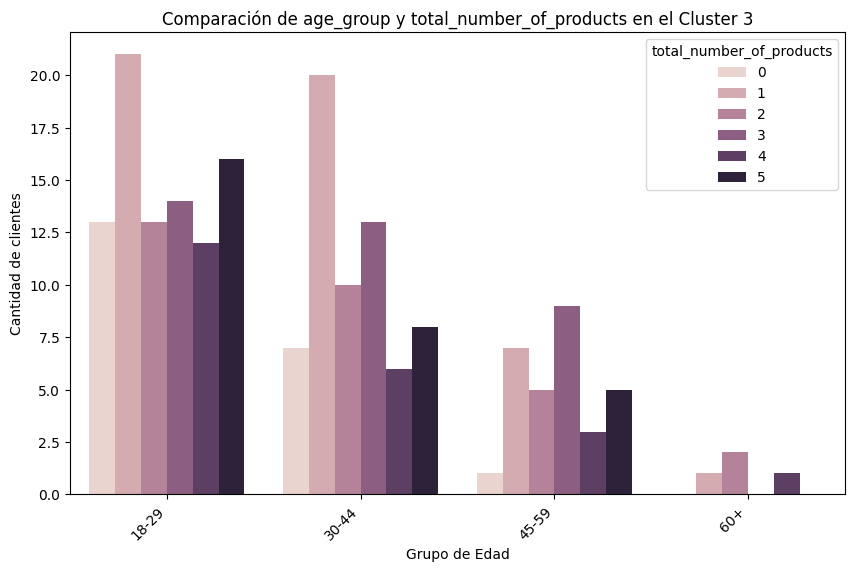

In [52]:

import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar el DataFrame para incluir solo el cluster 3
cluster_3 = data[data['cluster'] == 3]

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.countplot(x='age_group', hue='total_number_of_products', data=cluster_3)
plt.title('Comparación de age_group y total_number_of_products en el Cluster 3')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=45, ha='right')
plt.show()


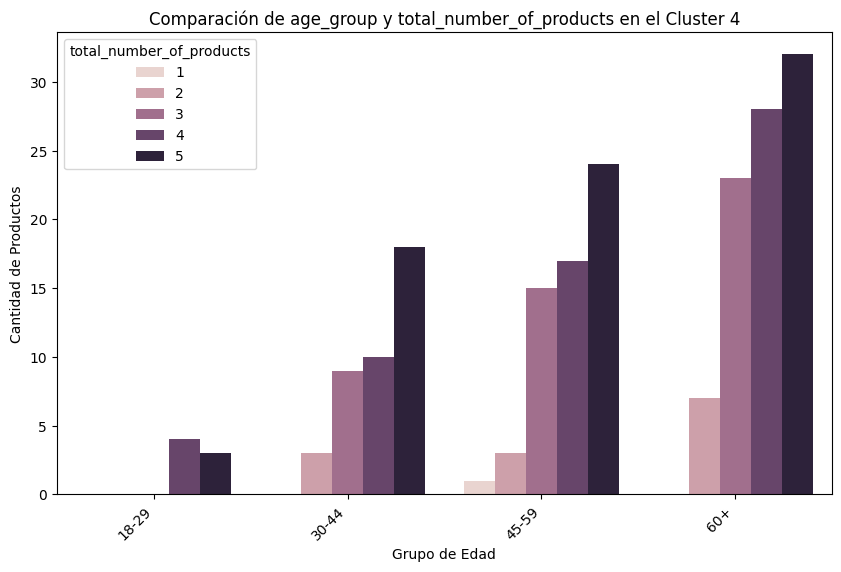

In [53]:

import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar el DataFrame para incluir solo el cluster 4
cluster_4 = data[data['cluster'] == 4]

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.countplot(x='age_group', hue='total_number_of_products', data=cluster_4)
plt.title('Comparación de age_group y total_number_of_products en el Cluster 4')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Productos')
plt.xticks(rotation=45, ha='right')
plt.show()


Edad vs ciudad

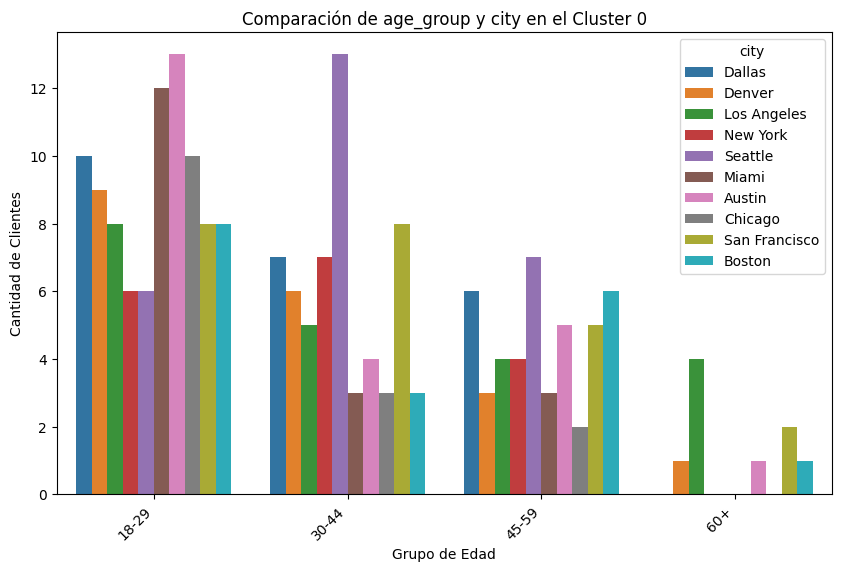

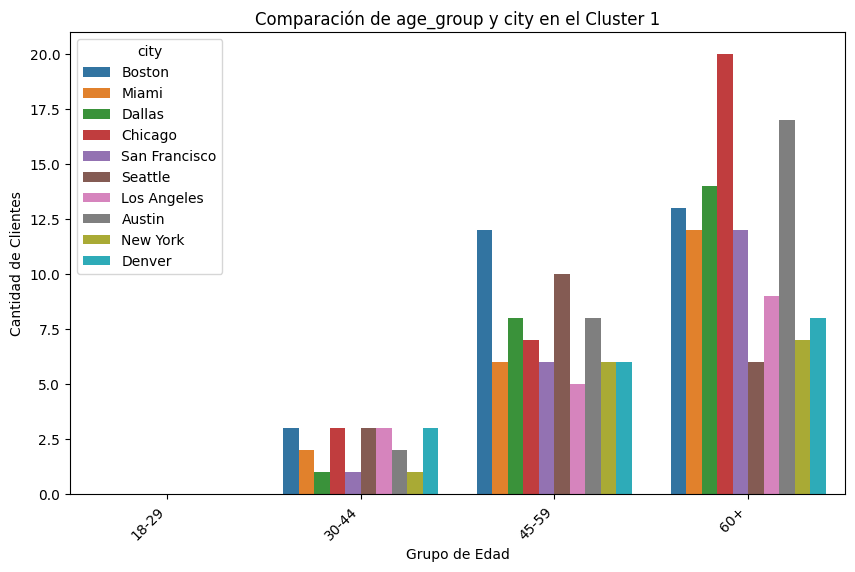

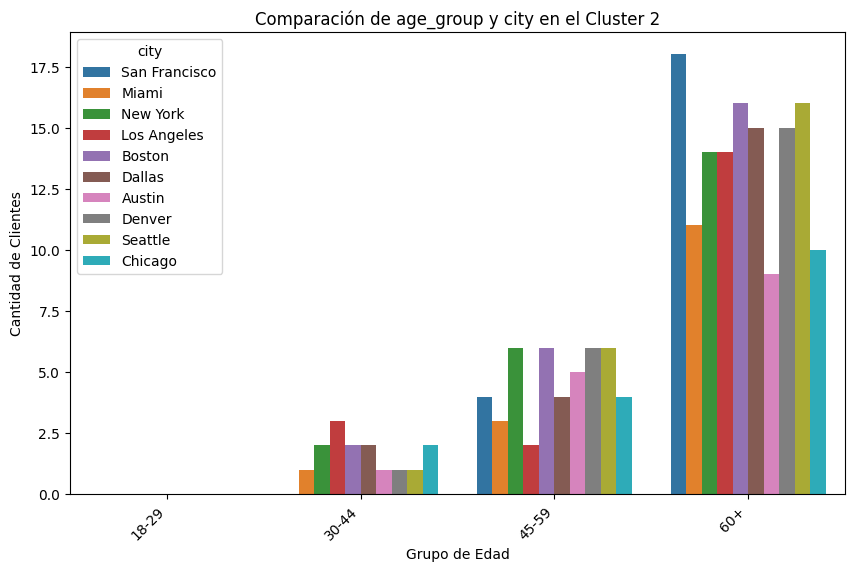

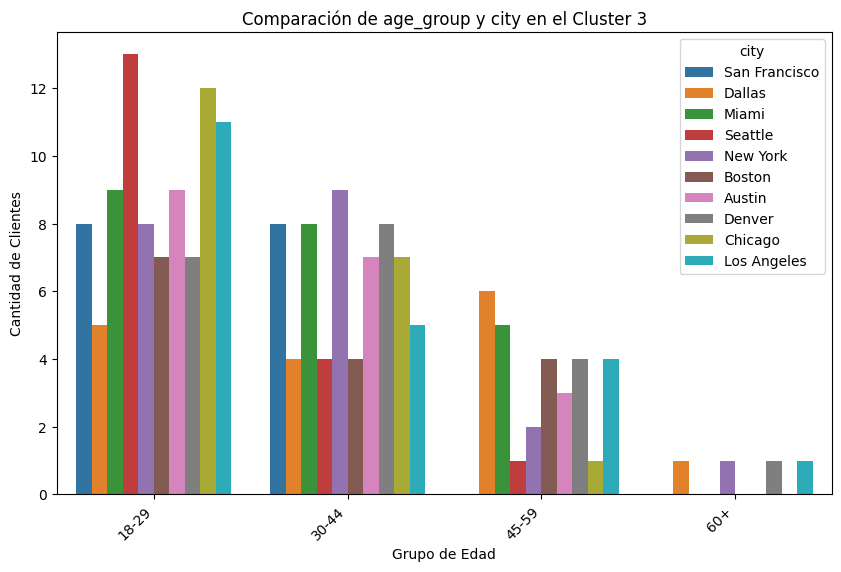

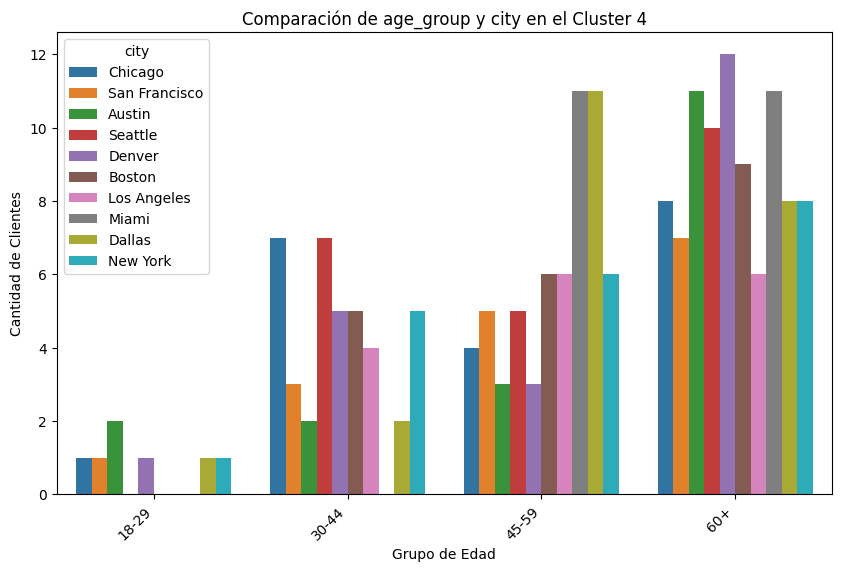

In [54]:

# Filtrar el DataFrame para incluir solo el cluster 0
cluster_0 = data[data['cluster'] == 0]

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.countplot(x='age_group', hue='city', data=cluster_0)
plt.title('Comparación de age_group y city en el Cluster 0')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=45, ha='right')
plt.show()

# Repetir el proceso para los demás clusters (1, 2, 3, 4)
for i in range(1, 5):
    cluster_i = data[data['cluster'] == i]
    plt.figure(figsize=(10, 6))
    sns.countplot(x='age_group', hue='city', data=cluster_i)
    plt.title(f'Comparación de age_group y city en el Cluster {i}')
    plt.xlabel('Grupo de Edad')
    plt.ylabel('Cantidad de Clientes')
    plt.xticks(rotation=45, ha='right')
    plt.show()


**Edad vs uso de tecnología y sedes**


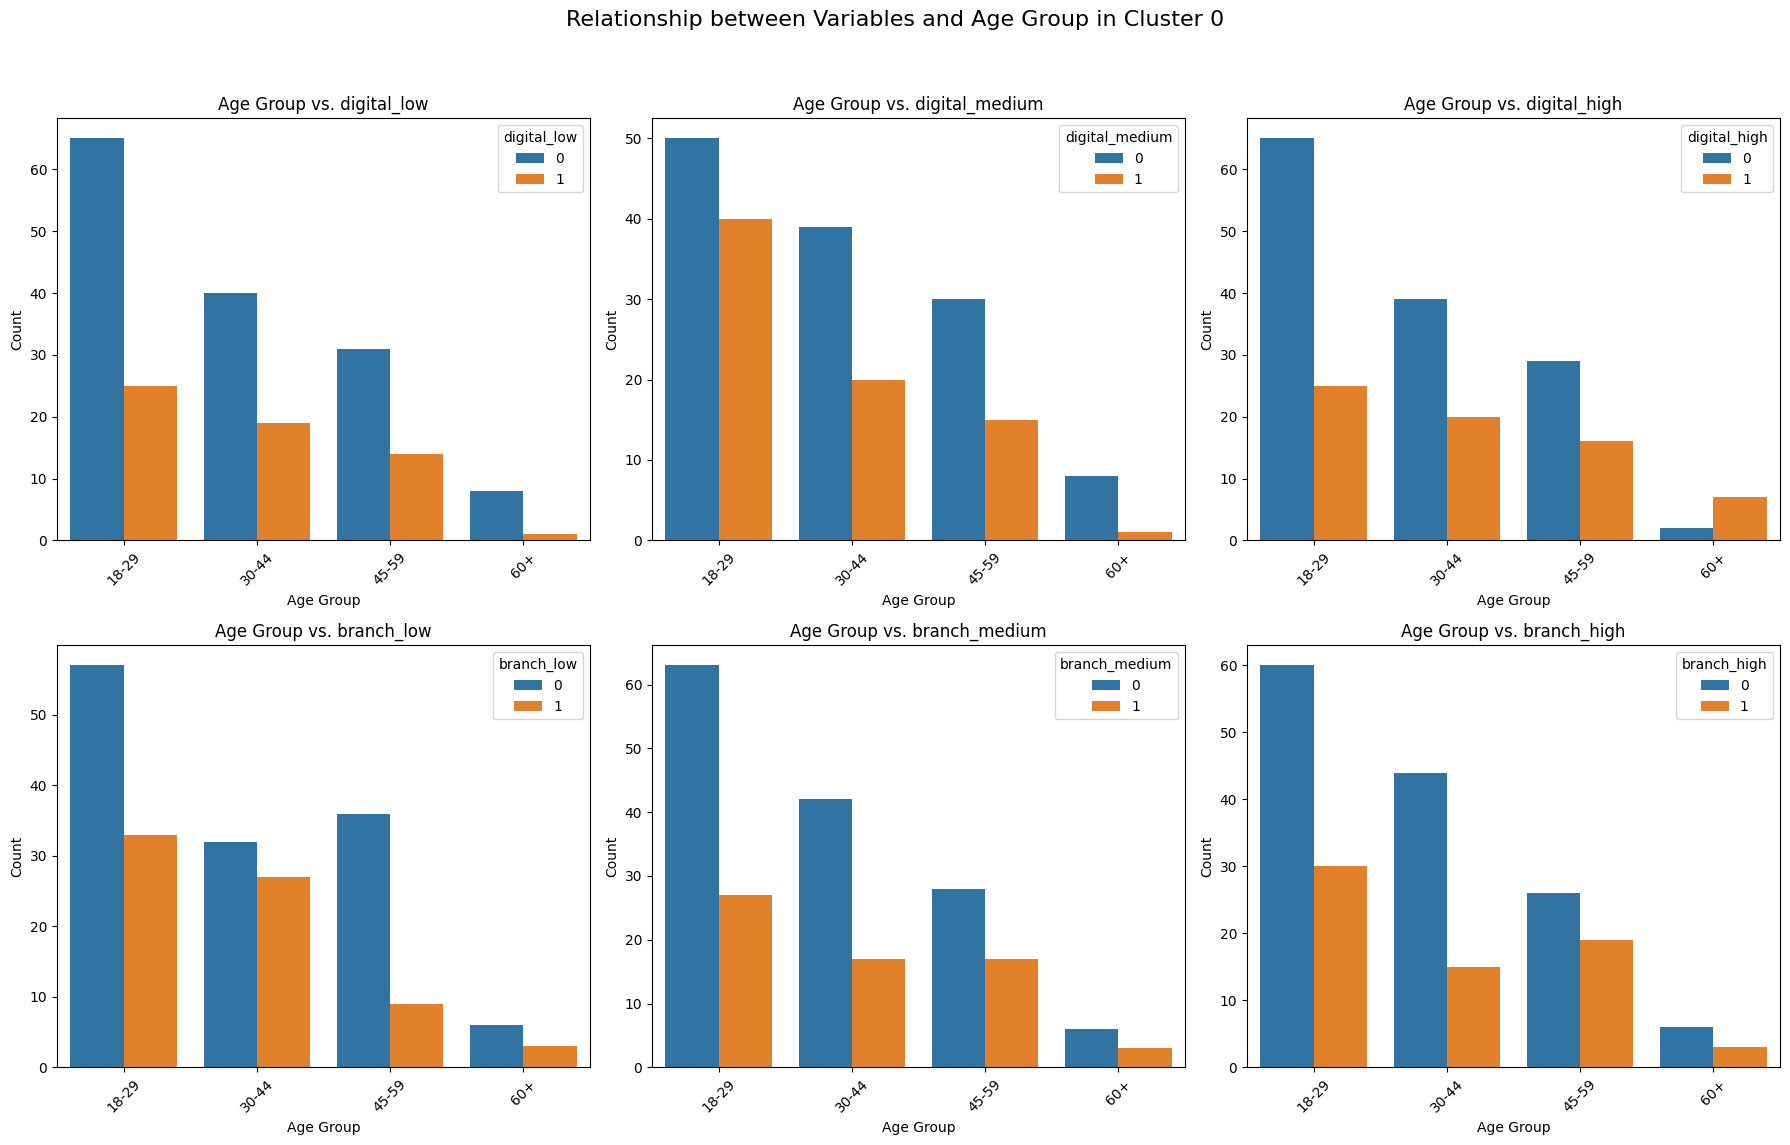

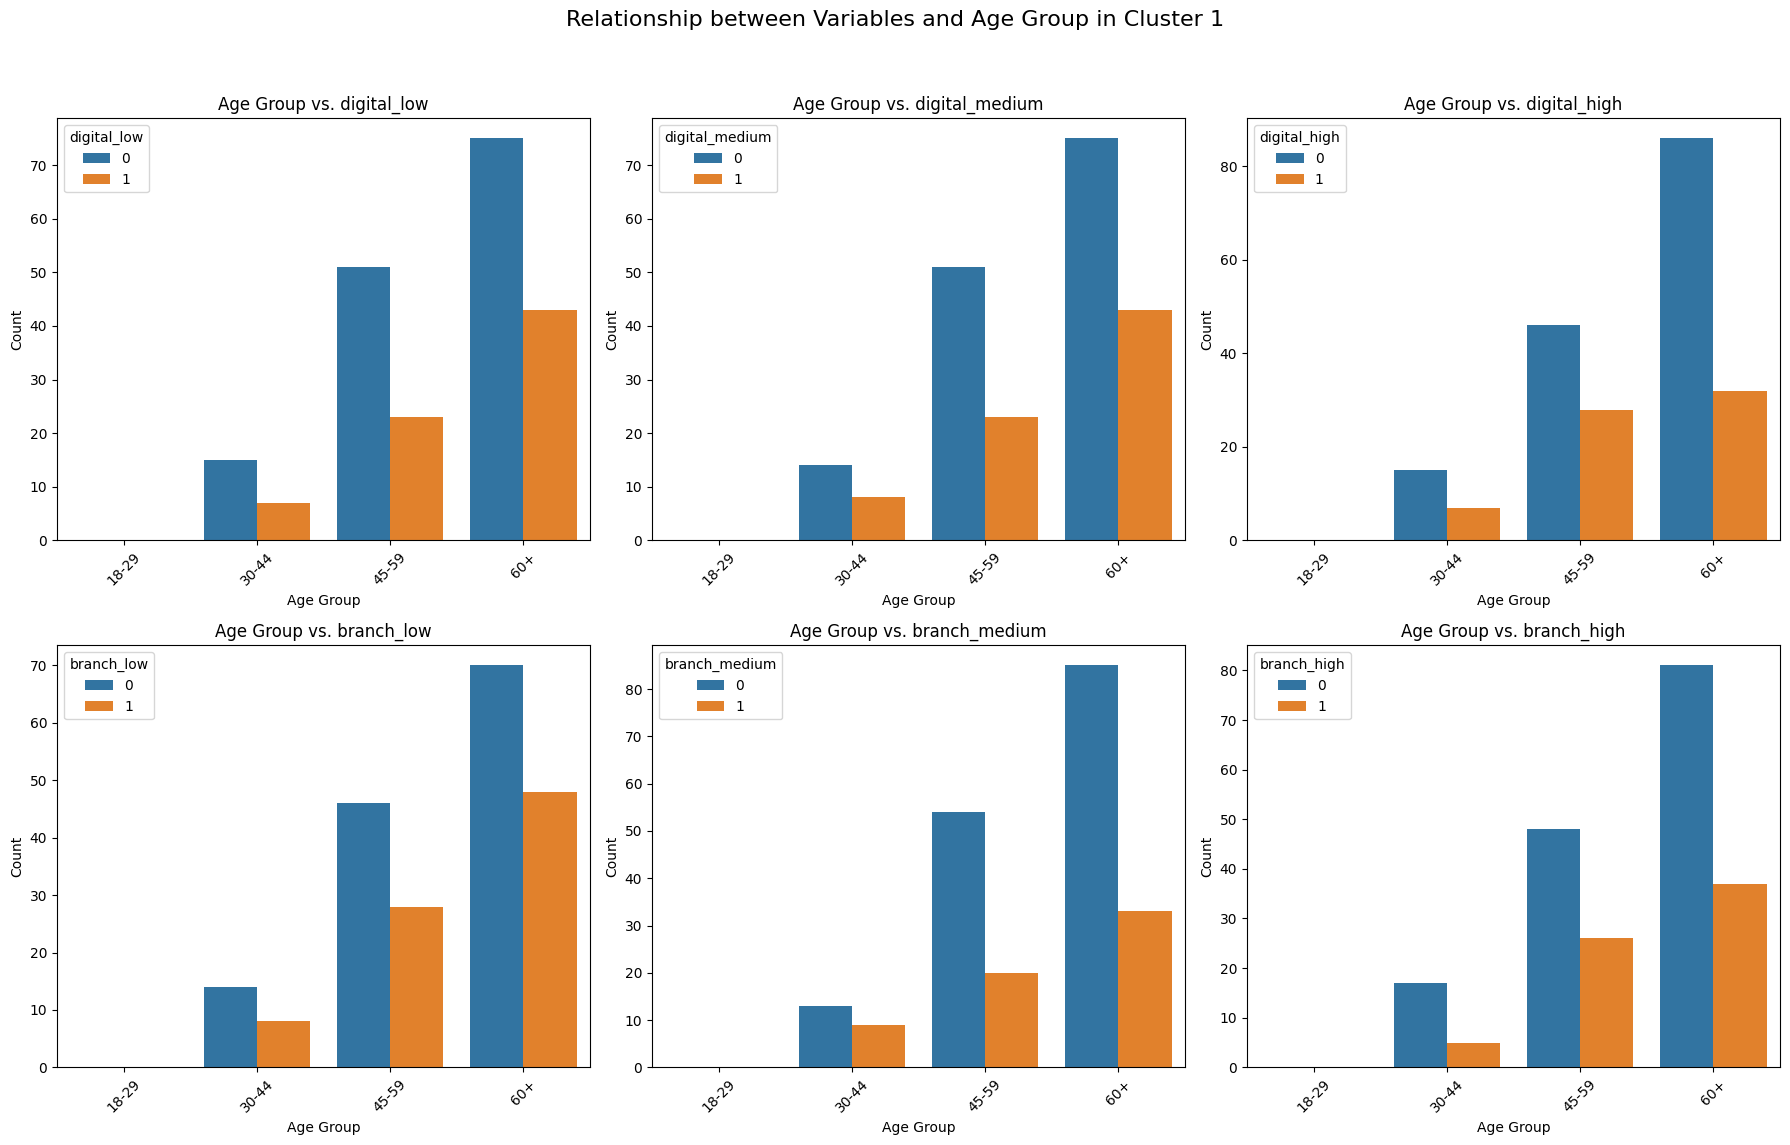

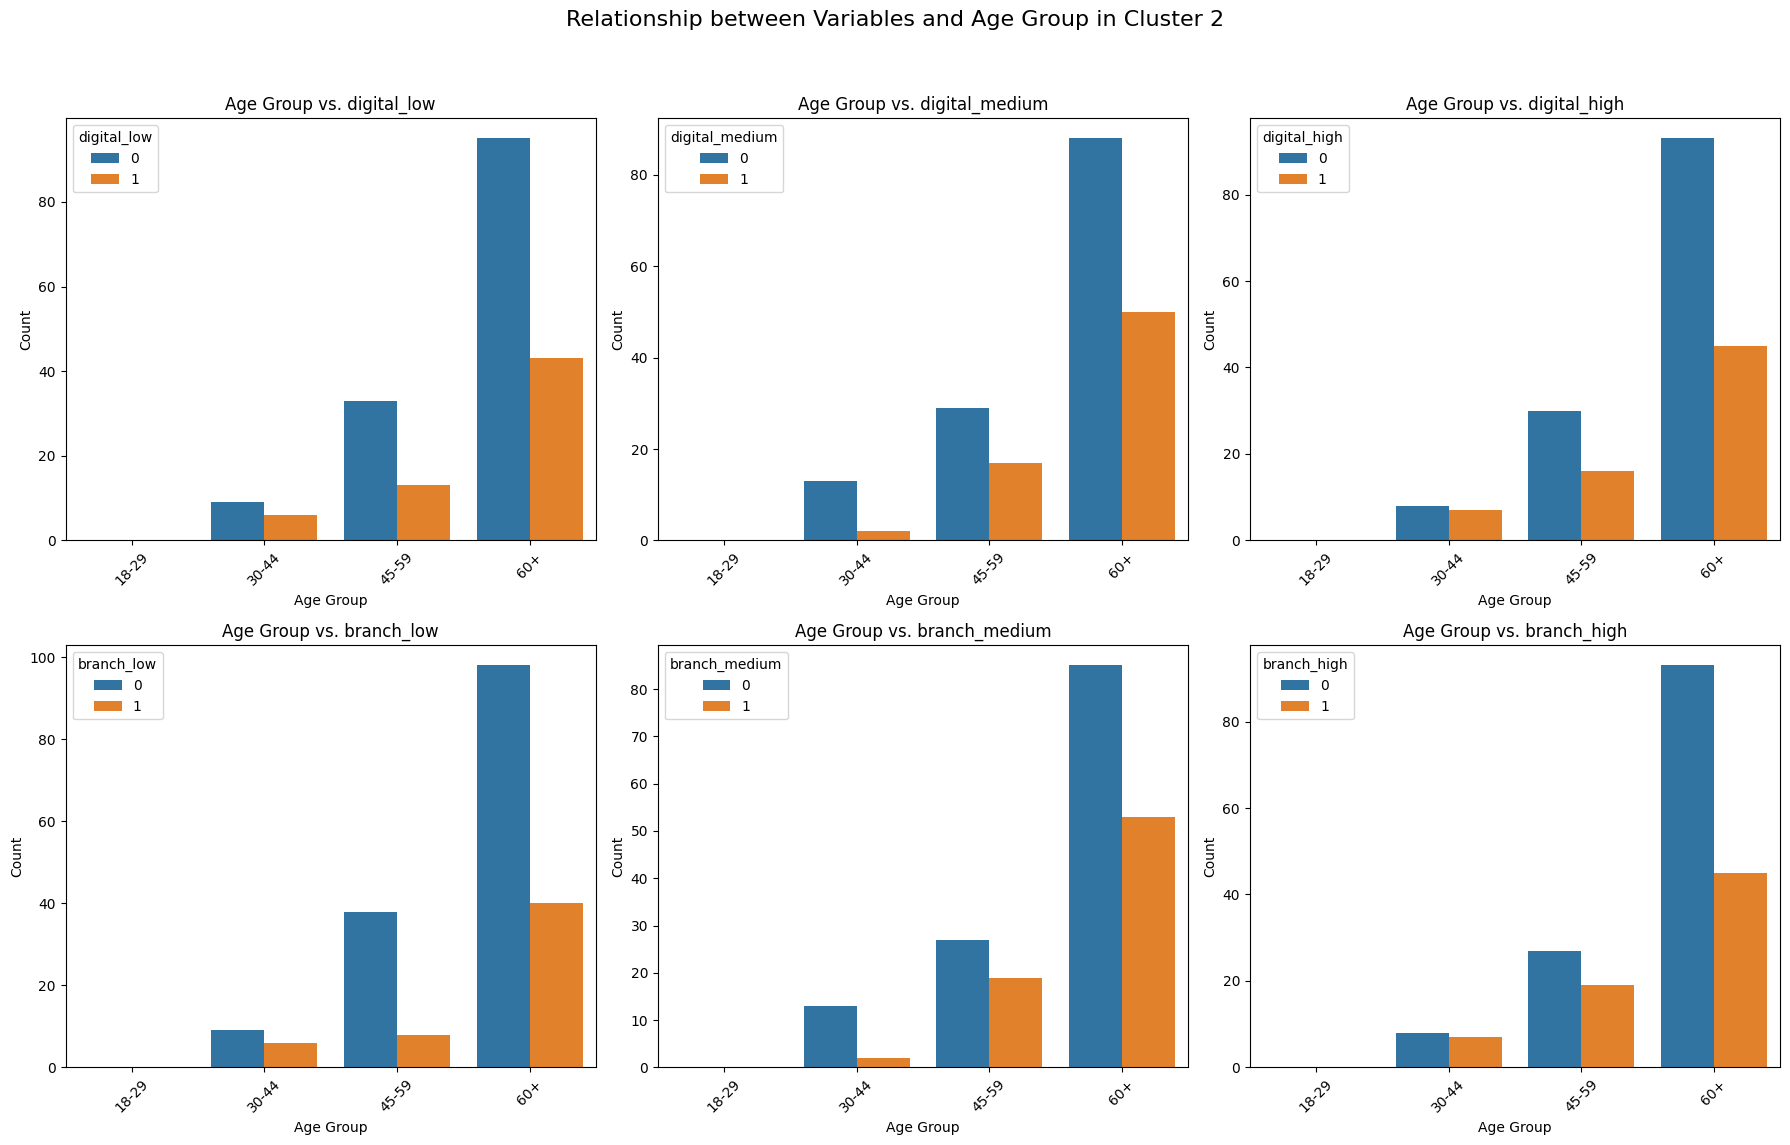

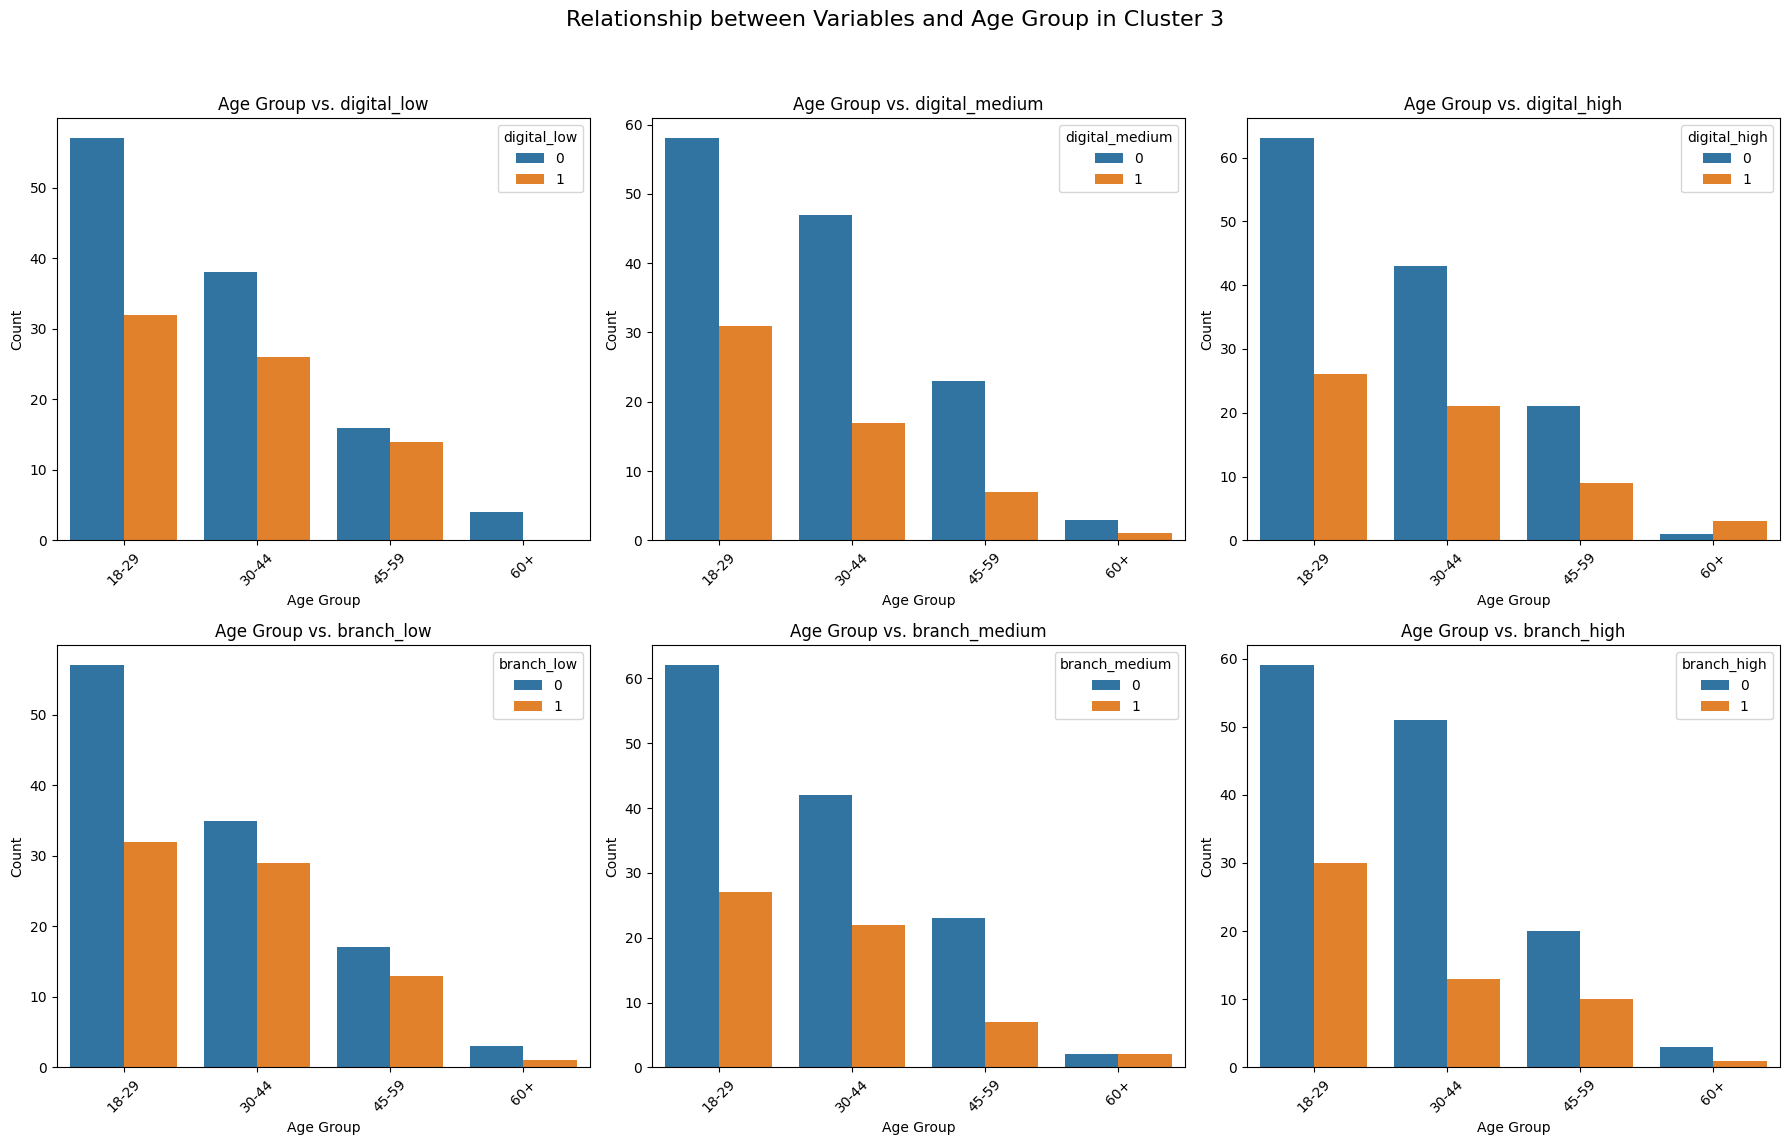

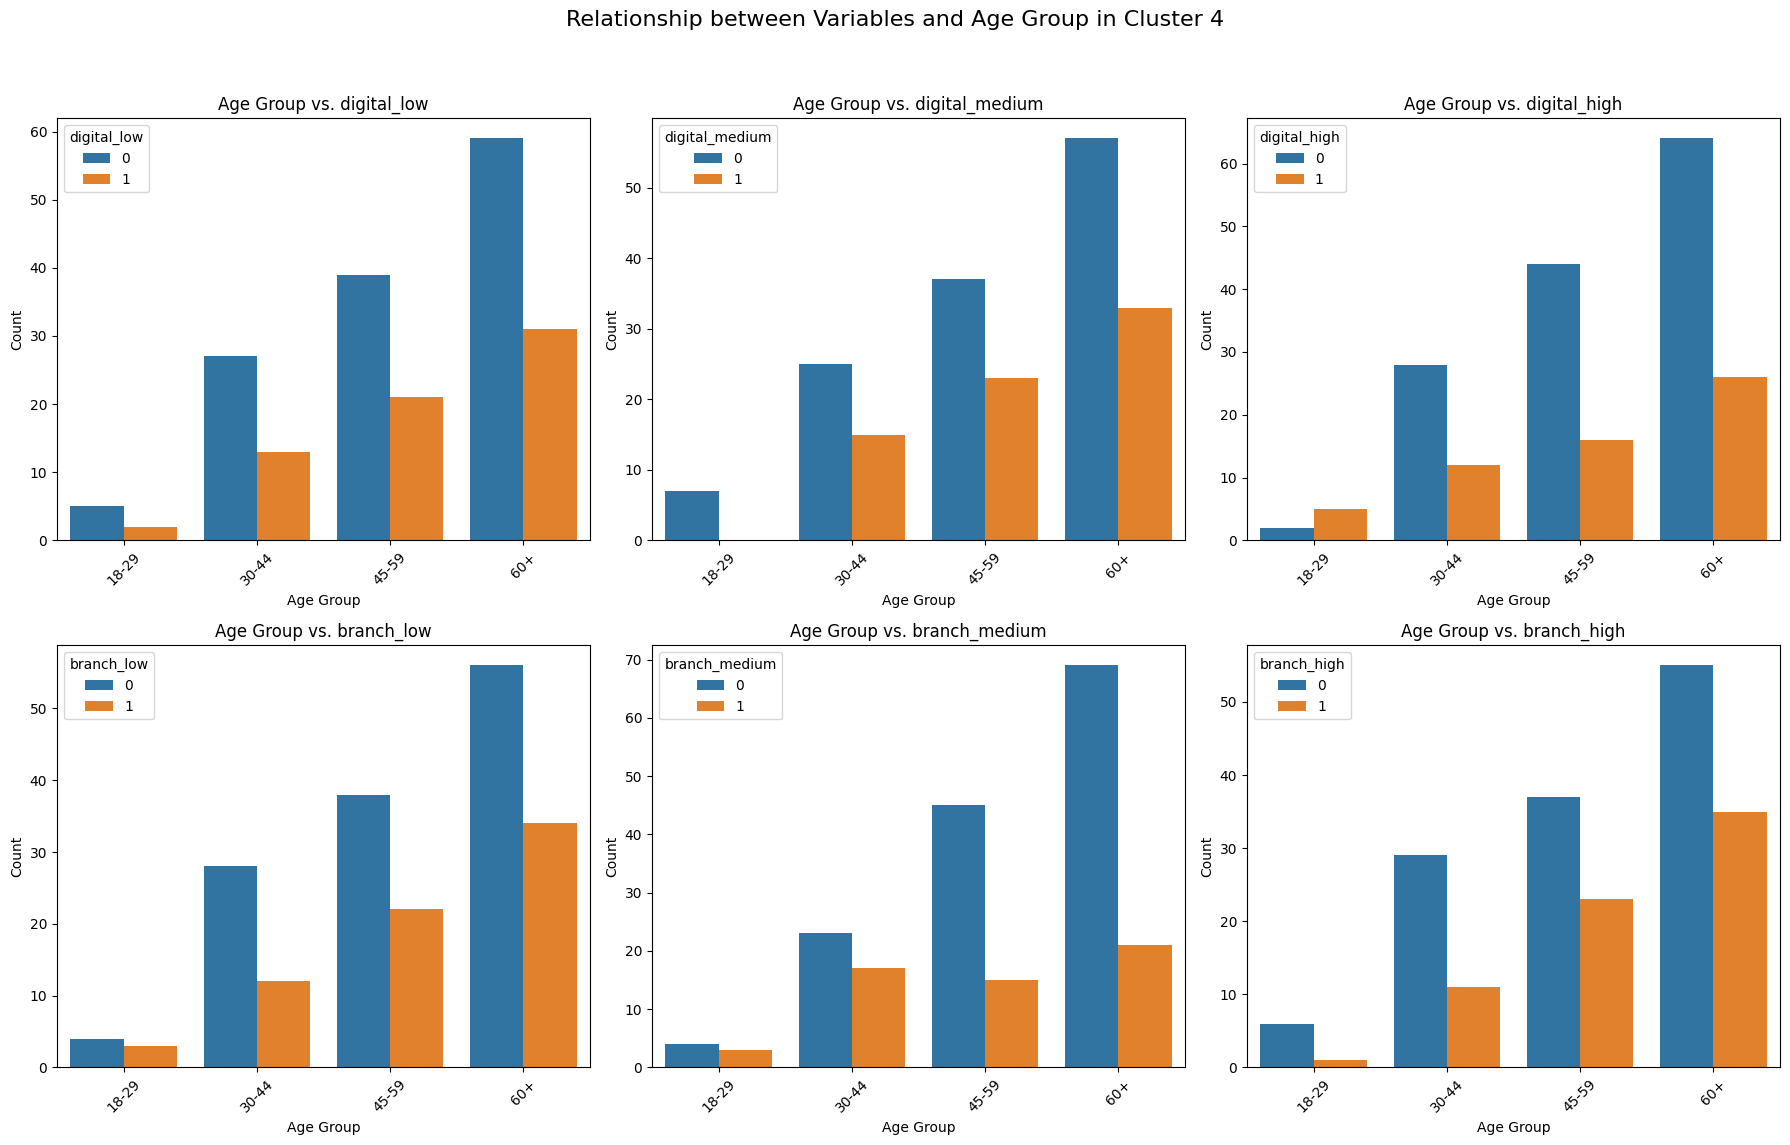

In [55]:

import matplotlib.pyplot as plt
import seaborn as sns

# Iterate through each cluster
for cluster_num in range(5):  # Assuming you have 5 clusters
    cluster_data = data[data['cluster'] == cluster_num]

    # Create a figure and axes for the plot
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'Relationship between Variables and Age Group in Cluster {cluster_num}', fontsize=16)

    # Define the variables to plot
    variables = ['digital_low', 'digital_medium', 'digital_high', 'branch_low', 'branch_medium', 'branch_high']

    # Plot each variable
    for i, var in enumerate(variables):
        row = i // 3
        col = i % 3
        sns.countplot(x='age_group', hue=var, data=cluster_data, ax=axes[row, col])
        axes[row, col].set_title(f'Age Group vs. {var}')
        axes[row, col].set_xlabel('Age Group')
        axes[row, col].set_ylabel('Count')
        axes[row, col].tick_params(axis='x', rotation=45)

    # Adjust layout and display the plot
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


## **Presentación de los hallazgos**

En el cluster 0:
*  Rango de edad 18-29:

Los ingresos se encuentran en su mayoría por debajo de 100.000 y por encima de 150.000.

La deuda tiene un valor mínimo de 200.000 y un valor máximo de 500.000, se concentra por encima de 350.000.

La antigüedad máxima es de 11 años.

La mayoría de clientes tiene 1, 3 o 5 productos.

La mayoría de clientes se encuentran en Austin, Miami, Chicago y Dallas.

La mayoría de clientes usan servicios digitales de forma moderada y pocas veces las sucursales físicas.

*  Rango de edad 30-44:

Los ingresos se encuentran repartidos por debajo de 200.000.

La deuda se concentra por encima de 250.000.

La antigüedad en el rango es entre 0 y 23, la mayoría es superior a 7 e inferior a 20 años.

La mayoría de clientes tiene 3 productos.

La mayoría de clientes se encuentran en Seattle y San Francisco.

La mayoría de clientes usan los servicios digitales ya sea pocas o muchas veces, y las sucursales pocas veces.

*  Rango de edad 45-59:

Los ingresos están repartidos por debajo de 150.000.

La deuda se concentra por encima de 300.000.

La antigüedad es entre 0 y 20 años en su mayoría, sin embargo hay registro de antigüedad superiorees a 25 años.

La mayoría de clientes tiene 1 producto.

La mayoría de clientes están en Seattle, Boston y Dallas.

La mayoría de clientes usan los servicios digitales y las sucursales físicas muchas veces.

*  Rango de edad 60+:

Los ingresos están repartidos por debajo de 150.000, aunque no hay tantos clientes de esta edad en el cluster.

La deuda se concentra por encima de 400.000.

La antigüedad de todos es inferior a 10 años.

La mayoría de clientes tiene dos productos.

La mayoría de clientes están en Los Angeles.

La mayoría de clientes usan los servicios digitales muchas veces y las sucursales físicas en su mayoría no las usan.



---



En el cluster 1:

*  Rango de edad 30-44:

La mayoría de clientes tienen ingresos entre los 100.000 y los 200.000 y una pequeña parte supera esta cifra.

La deuda tiene un valor mínimo de 0 y un valor máximo de 500.000, la mayoría de la deuda supera los 100.000 y se concentra por encima de 200.000.

La antigüedad en su mayoría supera los 15 y es inferior a 25 años, con un registro inferior a 15 y un registro superior a 25.

La mayoría de clientes tiene 1 producto o no tiene productos.

La mayoría de clientes están en Boston, Chicago, Seattle, Los Angeles y Denver.

En su mayoría no se usan los servicios digitales y las sucursales.

*  Rango de edad 45-59:

Los ingresos de los clientes están repartidos entre los 50.000 y los 250.000.

La deuda se concentra por debajo de 250.000, sin embargo hay presencia de deuda superior en proporciones similares.

La antigüedad en su mayoría supera los 10 años y es inferior 35 años.

La mayoría de clientes tiene un producto o no tiene productos.

La mayoría de clientes están en Boston, Seattle, Austin y Dallas.

La mayoría de clientes usan los servicios digitales muchas veces y las sucursales pocas veces.

*  Rango de edad 60+:

Los ingresos de los clientes se reparten hasta los 250.000, incluyendo los ingresos inferiores a 50.000.

La deuda se reparte sin una concentración clara evidente entre 0 y 500.000.

La antigüedad supera en su mayoría los 15 años.

La mayoría de clientes tiene 1 producto o no tiene productos.

La mayoría de clientes están en Chicago y Austin.

La mayoría usan los servicios digitales pocas veces o de forma moderada, y las sucursales pocas veces.

---

En el cluster 2:

*  Rango de edad 30-44:

La mayoría de ingresos están entre 25.000 y 75.000, con algunos por debajo de 25.000 y otros pocos por encima de 100.000.

La deuda se concentra entre 100.000 y 300.000, con algunos casos superiores a 400.000 y uno cercano a 0.

La antigüedad se registra entre 15 y 25 años.

La mayoría de clientes tiene 4 o 5 productos.

La mayoría de clientes están en Los Angeles, Nueva York, Boston, Dallas y Chicago.

La mayoría de clientes usan los servicios digitales y las sucursales muchas veces.

*  Rango de edad 45-59:

Los ingresos de la mayoría de los clientes son inferiores a 100.000 con algunos por encima de esta cifra.

La deuda se concentra por debajo de los 300.000, con algunos casos superiores a esta cifra e inferiores a 400.000.

La antigüedad se registra entre 10 y 33 años.

La mayoría de clientes tiene 5 clientes.

La mayoría de clientes están en Nueva York, Boston, Denver y Seattle.

La mayoría usa los servicios digitales y las sucursales físicas de forma moderada.

*  Rango de edad 60+:

Los ingresos se reparten entre los 25.000 y los 200.000, con la mayoría siendo inferior a 125.000.

La deuda se reparte entre 0 y 500.000 con concentraciones aparentes cada rango de 100.000.

La antigüedad se reparte uniformemente entre 0 y 35 años.

La mayoría de clientes tiene 3, 4 o 5 productos.

La mayoría de clientes están en San Francisco, Boston y Seattle.

La mayoría usa los servicios digitales y las sucursales físicas de forma moderada.

---

En el cluster 3:

*  Rango de edad 18-29:

Los ingresos se reparten entre los 50.000 y los 250.000, los ingresos entre 150 y 200 son el rango más denso.

La deuda abarca entre 0 y 350.000, la mayoría es inferior a 300.000.

La antigüedad se registra entre 0 y 11 años.

La mayoría de clientes tiene 1 o 5 productos.

La mayoría de clientes están en Seattle, Chicago y Los Angeles.

La mayoría usa los servicios digitales pocas veces o de forma moderada y las sucursales pocas veces.

*  Rango de edad 30-44:

Los ingresos están repartidos entre 50.000 y 250.000, no hay una concentración clara.

La deuda se concentra por debajo 250.000.

La antigüedad se registra entre 0 y 20 años, la mayoría se encuentra por debajo de 15 años.

La mayoría de clientes tiene 1 o 3 productos.

La mayoría de clientes están en Nueva York, San Francisco, Miami y Denver.

La mayoría usa los servicios digitales y las sucursales pocas veces.

*  Rango de edad 45-59:

Los ingresos se reparten entre los 50.000 y los 250.000, el rango entre 100.000 y 150.000 es el más denso.

La deuda se concentra por debajo de 200.000.

La antigüedad se registra entre 0 y 20 años, la mayoría de registros se encuentra por debajo de 10 años.

La mayoría de clientes tiene 3 productos.

La mayoría de clientes están en Dallas y Miami.

La mayoría usa los servicios digitales y las sucursales pocas veces.

*  Rango de edad 60+:

Hay unos pocos ingresos registrados repartidos entre 50.000 y 250.000.

Todos los registros de deuda son inferiores a 150.000.

Los registros de antigüedad son inferiores a 5 años.

La mayoría de clientes de clientes tiene 2 productos.

Los clientes están en Dallas, Nueva York, Denver y Los Angeles.

La mayoría usa los servicios digitales muchas veces y las sucursales de forma moderada.

---

En el cluster 4:

*  Rango de edad 18-29:

Todos los ingresos superan los 200.000.

Todos los registros de deuda se encuentran entre 300.000 y 500.000.

Los registros de antigüedad están entre 5 y 10 años.

Todos los clientes tienen 4 o 5 productos.

Los clientes están en Austin, Chicago, San Francisco, Denver, Dallas y Nueva York.

La mayoría usa los servicios digitales muchas veces y las sucursales pocas veces.

*  Rango de edad 30-44:

Los ingresos se reparten en su mayoría entre 180.000 y 240.000.

La deuda se reparte entre 100.000 y 500.000, la mayoría está por encima de 200.000.

Los registros de antigüedad están entre 5 y 25 años.

La mayoría de clientes tiene 5 productos.

La mayoría de clientes están en Chicago y Seattle.

La mayoría usa los servicios digitales y las sucursales de forma moderada.

*  Rango de edad 45-59:

Los ingresos se reparten en su mayoría entre 140.000 y 240.000.

La deuda en su mayoría supera los 300.000.

Los registros de antigüedad están en su mayoría entre 15 y 30 años.

La mayoría de clientes tiene 5 productos.

La mayoría de clientes están en Miami y Dallas.

La mayoría usa los servicios digitales de forma moderada y las sucursales muchas veces.

*  Rango de edad 60+:

Los ingresos se reparten en su mayoría entre 160.000 y 240.000.

La deuda en su mayoría supera los 200.000.

Los registros de antigüedad en su mayoría son inferiores a 20 años.

La mayoría de clientes tiene 5 productos.

La mayoría de clientes están en Denver, Austin, Miami y Seattle.

La mayoría usa los servicios digitales de forma moderada y las sucursales pocas veces.

## **Modelo guardado**

In [56]:
import joblib # Esta librería sirve para guardar y llamar objetos de Python, como los modelos de machine learning
joblib.dump(kmeans, 'kmeans_model.pkl') # Se guarda el modelo de kmeans en el objeto 'kmeans_model.pkl'
joblib.dump(scaler, 'scaler.pkl') # Se guardan los parametros con los que se estandarizaron los datos con los que se entreno el modelo de kmeans

['scaler.pkl']

## **Informe ejecutivo**

<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8" />
<meta name="viewport" content="width=device-width, initial-scale=1" />

<style>
  body {
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    margin: 20px;
    background: #f9f9f9;
    color: #333;
  }
  h1, h2, h3 {
    color: #004080;
  }
  section {
    background: #fff;
    border-radius: 8px;
    padding: 15px 20px;
    margin-bottom: 20px;
    box-shadow: 0 2px 8px rgba(0,0,0,0.1);
  }
  ul {
    margin: 8px 0 15px 20px;
  }
  .cluster-title {
    border-bottom: 2px solid #004080;
    padding-bottom: 5px;
  }
  .summary {
    font-style: italic;
    background: #e6f2ff;
    padding: 10px;
    border-left: 4px solid #004080;
    margin-bottom: 25px;
  }
</style>
</head>
<body>

<h1>Informe Ejecutivo: Análisis de Clusters de Clientes</h1>

<p class="summary">Este informe presenta un análisis detallado de los 5 clusters identificados, segmentados por rangos de edad, comportamiento financiero, ubicación y uso de servicios digitales y físicos. El objetivo es apoyar la comprensión estratégica para personalizar ofertas y mejorar el servicio al cliente.</p>

<section>
  <h2 class="cluster-title">Cluster 0: Jóvenes y Adultos Jóvenes con Deudas Elevadas</h2>
  <h3>Perfil General</h3>
  <ul>
    <li>Principalmente clientes jóvenes (18-44 años) con ingresos dispersos, predominando niveles bajos y medios.</li>
    <li>Deuda significativa, generalmente concentrada entre 250,000 y 500,000.</li>
    <li>Uso moderado de servicios digitales y escasa actividad en sucursales físicas para los más jóvenes; mayor uso simultáneo para edades de 45-59.</li>
    <li>Presencia destacada en Austin, Miami, Chicago, Dallas, Seattle y San Francisco.</li>
  </ul>
  <h3>Oportunidades</h3>
  <ul>
    <li>Campañas focalizadas a segmentos jóvenes con educación financiera sobre gestión de deuda.</li>
    <li>Fortalecer canales digitales para clientes con alta actividad digital y mejorar experiencia en sucursales para segmentos que las frecuentan más.</li>
  </ul>
</section>

<section>
  <h2 class="cluster-title">Cluster 1: Clientes con Menor Uso de Servicios y Cartera Conservadora</h2>
  <h3>Perfil General</h3>
  <ul>
    <li>Clientes mayores (30-60+) con ingresos medios, algunos con ausencia de productos financieros.</li>
    <li>Deuda concentrada principalmente por debajo de 250,000, con antigüedades elevadas en la relación con el banco.</li>
    <li>Predominan las bajas interacciones tanto en servicios digitales como físicos.</li>
    <li>Principal presencia en Boston, Chicago, Seattle, Los Angeles, Denver, Austin y Dallas.</li>
  </ul>
  <h3>Oportunidades</h3>
  <ul>
    <li>Impulsar adopción de productos mediante programas de fidelización y educación orientada a beneficios de productos existentes.</li>
    <li>Mayor comunicación para fomentar uso de servicios digitales y físicos, mejorando la experiencia para aumentar engagement.</li>
  </ul>
</section>

<section>
  <h2 class="cluster-title">Cluster 2: Clientes con Productos Diversificados y Uso Activo</h2>
  <h3>Perfil General</h3>
  <ul>
    <li>Segmentos entre 30 y 60+ años con ingresos principalmente bajos y medios.</li>
    <li>Alta cantidad de productos financieros (4-5) y deuda moderada a alta.</li>
    <li>Consumo activo de servicios digitales y presencia moderada a alta en sucursales.</li>
    <li>Ubicación destacada en grandes ciudades como Los Angeles, Nueva York, Boston, Dallas y Chicago.</li>
  </ul>
  <h3>Oportunidades</h3>
  <ul>
    <li>Ofertas personalizadas para clientes con múltiples productos y segmentación basada en antigüedad y monto de deuda.</li>
    <li>Optimización y promoción de canales digitales y sucursales para mejorar retención y satisfacción.</li>
  </ul>
</section>

<section>
  <h2 class="cluster-title">Cluster 3: Adultos con Ingresos Medios y Baja Deuda</h2>
  <h3>Perfil General</h3>
  <ul>
    <li>Clientes con ingresos entre 50,000 y 250,000, con deuda generalmente baja (menor a 300,000).</li>
    <li>Productos financieros limitados (1-3), con presencia en ciudades clave como Seattle, Chicago, Nueva York y Miami.</li>
    <li>Uso moderado o escaso de servicios digitales y sucursales.</li>
    <li>Antigüedad corta, principalmente menos de 15 años.</li>
  </ul>
  <h3>Oportunidades</h3>
  <ul>
    <li>Promocionar productos para fomentar mayor diversificación financiera.</li>
    <li>Incentivar el uso de servicios digitales mediante campañas de educación y facilidades online.</li>
  </ul>
</section>

<section>
  <h2 class="cluster-title">Cluster 4: Clientes de Altos Ingresos y Alta Participación Financiera</h2>
  <h3>Perfil General</h3>
  <ul>
    <li>Clientes con ingresos elevados (por encima de 180,000), deuda significativa y alta antigüedad con el banco.</li>
    <li>Poseen múltiples productos financieros (4-5) y uso activo de servicios digitales.</li>
    <li>Ubicados en ciudades principales como Austin, Chicago, San Francisco, Denver, Dallas, Miami y Nueva York.</li>
    <li>Balance entre uso moderado de sucursales físicas y alta frecuencia digital.</li>
  </ul>
  <h3>Oportunidades</h3>
  <ul>
    <li>Desarrollar programas de fidelización premium y asesoría financiera personalizada para retener clientes de alto valor.</li>
    <li>Fortalecer la experiencia omnicanal para clientes con múltiples productos y mayores necesidades financieras.</li>
  </ul>
</section>


</body>
</html>



# Análisis y clasificación de la satisfacción de los clientes

In [57]:
import pandas as pd
from textblob import TextBlob
import csv
import re
import time
import string

In [58]:
print(data['bank_service_message'])

0      I've had an excellent experience with the bank...
1      I've had an excellent experience with the bank...
2      My recent interactions with the bank have been...
3      I've had an excellent experience with the bank...
4      My experience with the bank has been generally...
                             ...                        
995    I've had an excellent experience with the bank...
996    I've had an excellent experience with the bank...
997    I've had an excellent experience with the bank...
998    I've had an excellent experience with the bank...
999    I've had an excellent experience with the bank...
Name: bank_service_message, Length: 1000, dtype: object


## **Procesamiento de los mensajes**

In [59]:
def clean_text(text):
  text = re.sub(r'^RT[\s]+', '', text)
  text = re.sub(r'https?:\/\/.*[\r\n]*', '', text)
  text = re.sub(r'#', '', text)
  text = re.sub(r'@[A-Za-z0-9]+', '', text)
  return text

In [60]:
data['clean_text'] = data['bank_service_message'].apply(clean_text)

In [61]:
data['clean_text']

,clean_text
0,I've had an excellent experience with the bank...
1,I've had an excellent experience with the bank...
2,My recent interactions with the bank have been...
3,I've had an excellent experience with the bank...
4,My experience with the bank has been generally...
...,...
995,I've had an excellent experience with the bank...
996,I've had an excellent experience with the bank...
997,I've had an excellent experience with the bank...
998,I've had an excellent experience with the bank...


In [62]:
import re

def remove_emojis(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticones
                           u"\U0001F300-\U0001F5FF"  # simbolos & pictogramas
                           u"\U0001F680-\U0001F6FF"  # simbolos de mapas y transporte
                           u"\U0001F1E0-\U0001F1FF"  # banderas (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

data['clean_text'] = data['clean_text'].apply(remove_emojis)

In [63]:
data['clean_text']

,clean_text
0,I've had an excellent experience with the bank...
1,I've had an excellent experience with the bank...
2,My recent interactions with the bank have been...
3,I've had an excellent experience with the bank...
4,My experience with the bank has been generally...
...,...
995,I've had an excellent experience with the bank...
996,I've had an excellent experience with the bank...
997,I've had an excellent experience with the bank...
998,I've had an excellent experience with the bank...


In [65]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return " ".join(filtered_words)

data['clean_text'] = data['clean_text'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## **Creación niveles de satisfacción**

In [66]:
def get_polarity(text):
  analysis = TextBlob(text).sentiment
  return analysis.polarity

In [67]:
data['polarity'] = data['clean_text'].apply(get_polarity)

In [68]:
data['polarity'].head(3)

,polarity
0,0.322857
1,0.376667
2,-0.075000


In [69]:
data[data.polarity < 0.3][['bank_service_message', 'polarity']].head()

,bank_service_message,polarity
2,My recent interactions with the bank have been...,-0.075000
4,My experience with the bank has been generally...,0.192517
6,My experience with the bank has been generally...,0.199702
7,My recent interactions with the bank have been...,-0.075000
10,My experience with the bank has been generally...,0.206803


In [70]:
def x_range(x):
  if x > 0:
    return 1
  elif x == 0:
    return 0
  else:
    return -1

In [71]:
data['result'] = data['polarity'].apply(x_range)

In [74]:
data[['bank_service_message', 'polarity', 'result']].head(3)

,bank_service_message,polarity,result
0,I've had an excellent experience with the bank...,0.322857,1
1,I've had an excellent experience with the bank...,0.376667,1
2,My recent interactions with the bank have been...,-0.075000,-1


In [75]:
data['result'].value_counts()

,count
result,
1,788
-1,212


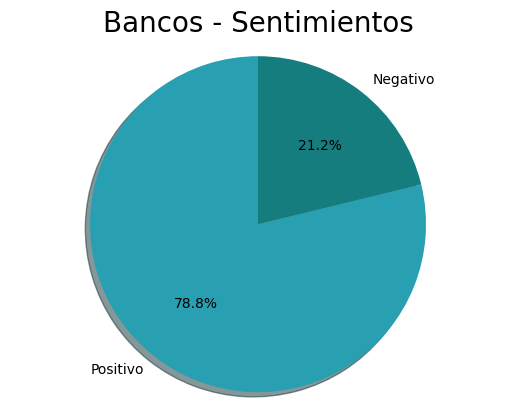

In [81]:
import matplotlib.pyplot as plt
labels = 'Positivo', 'Negativo'
colors = ['#29A0B1','#167D7F','#98D7C2']
plt.pie(data['result'].value_counts(), labels = labels, colors = colors,
        autopct = '%1.1f%%', shadow = True, startangle = 90)
plt.title('Bancos - Sentimientos', fontsize = 20)
plt.axis('equal')
plt.show()

In [78]:
from wordcloud import WordCloud
text = ' '.join(data.clean_text)
text

"excellent experience bank's helpful financial advice. team consistently supportive, using services made managing finances much easier. digital banking in-person interactions, everything feels smooth efficient. highly recommend service anyone looking reliability. excellent experience bank's fraud protection efficiency. team consistently supportive, using services made managing finances much easier. digital banking in-person interactions, everything feels smooth efficient. highly recommend service anyone looking reliability. recent interactions bank disappointing, particularly related unreliable mobile app. Customer support slow respond, encountered multiple obstacles trying resolve basic issues. overall banking experience left much desired, pushing consider alternatives. excellent experience bank's seamless online banking. team consistently supportive, using services made managing finances much easier. digital banking in-person interactions, everything feels smooth efficient. highly re

In [79]:
wordcloud = WordCloud(width=1024, height=800, colormap='Blues', min_font_size=14).generate(text)

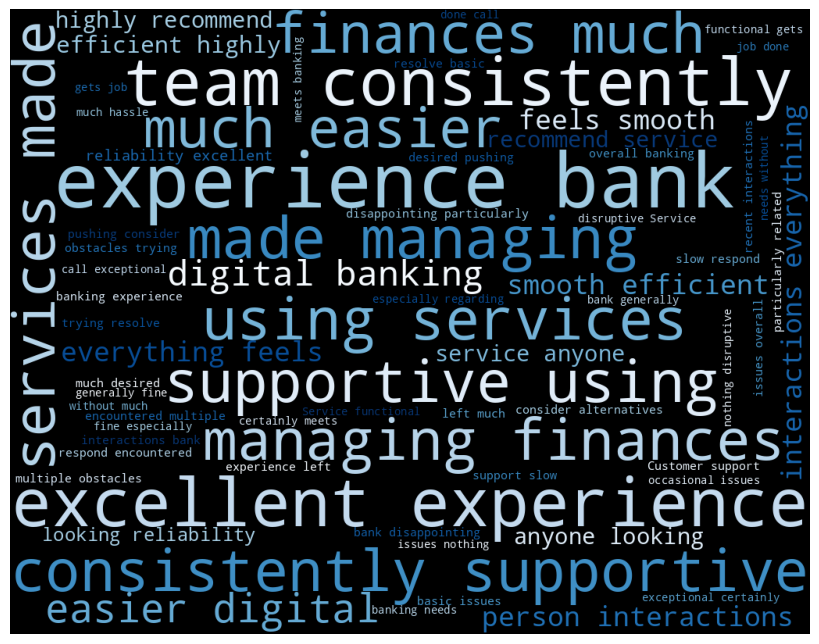

In [80]:
plt.figure(figsize= (8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad = 0)
plt.show()

## **Análisis de clusters**

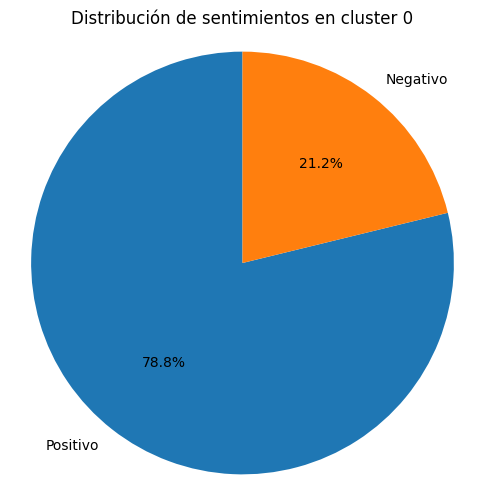

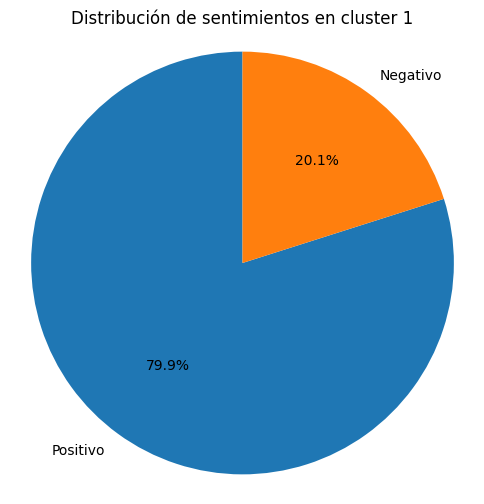

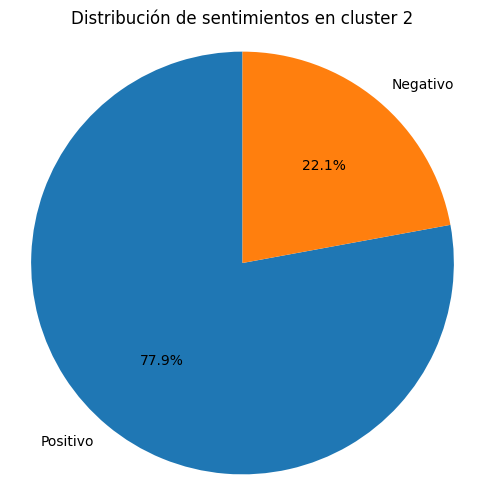

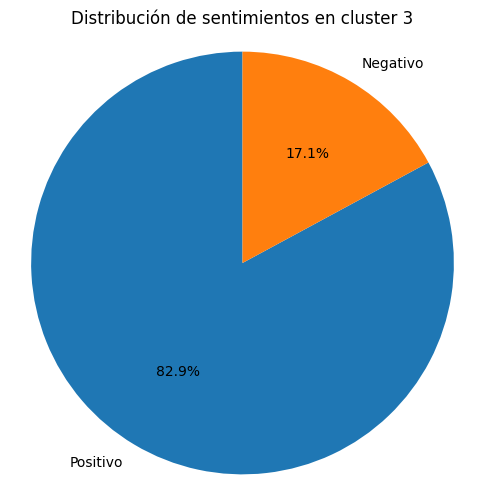

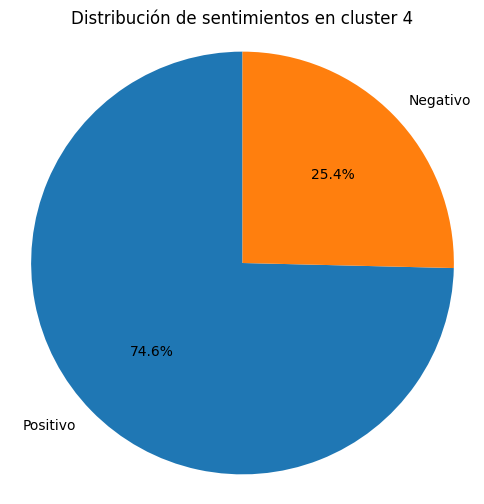

In [89]:
# Crear el gráfico por cada cluster
for cluster in range(5):
    cluster_data = data[data['cluster'] == cluster]
    sentiment_counts = cluster_data['result'].value_counts()

    # Verificar si ambos sentimientos existen en el cluster
    if 1 in sentiment_counts and -1 in sentiment_counts:
        labels = ['Positivo', 'Negativo']
        sizes = [sentiment_counts[1], sentiment_counts[-1]]

        plt.figure(figsize=(6, 6))  # Ajustar la figura
        plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
        plt.title(f'Distribución de sentimientos en cluster {cluster}')
        plt.axis('equal')  # Asegura que el gráfico se dibuje como un círculo.
        plt.show()
    else:
        print(f"Cluster {cluster} no tiene sentimientos positivos y negativos.")


In [90]:

def analyze_cluster_sentiment(data, cluster_num):
    cluster_data = data[data['cluster'] == cluster_num]
    positive_reviews = cluster_data[cluster_data['result'] == 1]['bank_service_message']
    negative_reviews = cluster_data[cluster_data['result'] == -1]['bank_service_message']

    print(f"Análisis cluster {cluster_num}:")

    if not positive_reviews.empty:
        print("\nRazones sentimientos positivos:")
        for review in positive_reviews.head():
            print(review)

    else:
        print("\nNo se encontraron sentimientos positivos en este cluster.")

    if not negative_reviews.empty:
        print("\nRazones sentimientos negativos:")
        for review in negative_reviews.head():
            print(review)

    else:
        print("\nNo se encontraron sentimientos negativos en este cluster.")


for i in range(5):
  analyze_cluster_sentiment(data, i)


Análisis cluster 0:

Razones sentimientos positivos:
I've had an excellent experience with the bank's fraud protection efficiency. Their team is consistently supportive, and using their services has made managing my finances much easier. From digital banking to in-person interactions, everything feels smooth and efficient. I highly recommend their service to anyone looking for reliability.
My experience with the bank has been generally fine, especially regarding average service quality. There have been occasional issues but nothing too disruptive. Service is functional and gets the job done. I wouldn't call it exceptional, but it certainly meets most of my banking needs without much hassle.
I've had an excellent experience with the bank's mobile check deposits. Their team is consistently supportive, and using their services has made managing my finances much easier. From digital banking to in-person interactions, everything feels smooth and efficient. I highly recommend their service t

In [87]:
import nltk
from nltk.probability import FreqDist
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

def analyze_cluster_word_frequency(data, cluster_num):
    cluster_data = data[data['cluster'] == cluster_num]
    positive_reviews = cluster_data[cluster_data['result'] == 1]['bank_service_message']
    negative_reviews = cluster_data[cluster_data['result'] == -1]['bank_service_message']
    stop_words = set(stopwords.words('english'))

    def preprocess_text(text):
        words = word_tokenize(text.lower())
        words = [w for w in words if w.isalnum() and w not in stop_words]  # Remover puntuación y stopwords
        return words


    print(f"\nAnálisis cluster {cluster_num}:")

    if not positive_reviews.empty:
        positive_words = []
        for review in positive_reviews:
          positive_words.extend(preprocess_text(review))
        freq_dist_positive = FreqDist(positive_words)
        print("\nPalabras más frecuentes en comentarios positivos:")
        print(freq_dist_positive.most_common(10))


    else:
        print("\nNo se encontraron sentimientos positivos en el cluster.")

    if not negative_reviews.empty:
        negative_words = []
        for review in negative_reviews:
          negative_words.extend(preprocess_text(review))
        freq_dist_negative = FreqDist(negative_words)
        print("\nPalabras más frecuentes en comentarios negativos:")
        print(freq_dist_negative.most_common(10))  # Print top 10 frequent words

    else:
        print("\nNo se encontraron sentimientos negativos en el cluster.")


for i in range(5):  # Assuming you have 5 clusters
    analyze_cluster_word_frequency(data, i)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.



Analysis for Cluster 0:

Most Frequent Words in Positive Reviews:
[('service', 177), ('banking', 174), ('experience', 164), ('bank', 160), ('much', 160), ('excellent', 119), ('team', 119), ('consistently', 119), ('supportive', 119), ('using', 119)]

Most Frequent Words in Negative Reviews:
[('banking', 50), ('customer', 45), ('slow', 44), ('recent', 43), ('interactions', 43), ('bank', 43), ('disappointing', 43), ('particularly', 43), ('related', 43), ('support', 43)]

Analysis for Cluster 1:

Most Frequent Words in Positive Reviews:
[('service', 186), ('banking', 179), ('experience', 176), ('bank', 171), ('much', 171), ('excellent', 132), ('team', 132), ('consistently', 132), ('supportive', 132), ('using', 132)]

Most Frequent Words in Negative Reviews:
[('slow', 51), ('customer', 47), ('banking', 46), ('recent', 43), ('interactions', 43), ('bank', 43), ('disappointing', 43), ('particularly', 43), ('related', 43), ('support', 43)]

Analysis for Cluster 2:

Most Frequent Words in Posit

## Caracterización sentimiento y otras variables

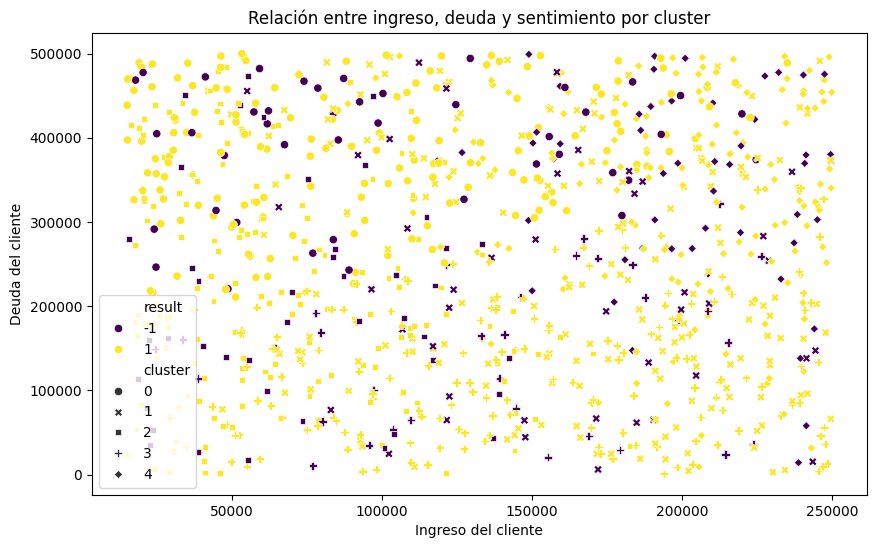

In [93]:

plt.figure(figsize=(10, 6))
sns.scatterplot(x='customer_income', y='customer_debt', hue='result', data=data, palette='viridis', style='cluster')
plt.title('Relación entre ingreso, deuda y sentimiento por cluster')
plt.xlabel('Ingreso del cliente')
plt.ylabel('Deuda del cliente')
plt.show()


# Informe ejecutivo de resultados

## 1. Introducción
Este informe combina el análisis de la relación entre ingreso, deuda y sentimiento de los clientes, segmentando los datos por clústeres. La información derivada de las reseñas también se ha incorporado para proporcionar un contexto más completo sobre las percepciones de los clientes.

## 2. Análisis de la Gráfica
La gráfica representa un diagrama de dispersión que articula la relación entre el ingreso del cliente y la deuda, diferenciando los puntos de datos por el resultado de un análisis de sentimiento.

### 2.1 Variables Clave
- **Ingreso del Cliente**: Rango de 50,000 a 250,000.
- **Deuda del Cliente**: Rango de 0 a 500,000.
- **Resultado del Sentimiento**:
  - -1: Sentimiento negativo (puntos púrpuras).
  - 1: Sentimiento positivo (puntos amarillos).

### 2.2 Clústeres Identificados
- **Clúster 0**: Círculos negros.
- **Clúster 1**: Cruces amarillas.
- **Clúster 2**: Cruces celestes.
- **Clúster 3**: Cruces moradas.
- **Clúster 4**: Estrellas azules.

## 3. Análisis de Clústeres

### Clúster 0
- **Palabras Frecuentes en Reseñas Positivas**: service, banking, experience.
- **Palabras Frecuentes en Reseñas Negativas**: slow, customer, disappointing.

### Clúster 1
- **Palabras Frecuentes en Reseñas Positivas**: service, banking, experience.
- **Palabras Frecuentes en Reseñas Negativas**: slow, customer, disappointing.

### Clúster 2
- **Palabras Frecuentes en Reseñas Positivas**: service, banking, experience.
- **Palabras Frecuentes en Reseñas Negativas**: slow, customer, disappointing.

### Clúster 3
- **Palabras Frecuentes en Reseñas Positivas**: service, banking, experience.
- **Palabras Frecuentes en Reseñas Negativas**: customer, slow, disappointing.

### Clúster 4
- **Palabras Frecuentes en Reseñas Positivas**: service, banking, experience.
- **Palabras Frecuentes en Reseñas Negativas**: slow, customer, disappointing.

## 4. Observaciones Principales
- **Distribución de Deuda**: La deuda es alta en clústeres con sentimientos negativos, sugiriendo que clientes con mayores deudas muestran insatisfacción.
- **Ingreso vs. Sentimiento**: Se observa que clientes con ingresos moderados a altos tienden a tener sentimientos negativos.
- **Agrupación por Clústeres**: No hay patrones claros en relación con el ingreso, pero hay variabilidad significativa en la deuda, especialmente en los clústeres negativos.

## 5. Conclusiones y Recomendaciones

### Conclusiones
- Existe una relación compleja entre ingreso, deuda y sentimiento.
- La calidad del servicio y la experiencia son percepciones comunes en los comentarios positivos, mientras que la lentitud es una queja recurrente.

### Recomendaciones
- Investigar las causas del sentimiento negativo en clientes de altos ingresos.
- Desarrollar estrategias personalizadas para manejar la deuda.
- Abordar las quejas relacionadas con la lentitud en el servicio para mejorar la satisfacción.
